<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/MGGF_General.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to /contend/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# New Figure 8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 59.9 MB/s eta 0:00:00
GRID HIERARCHY
G0 cells: 2562
G1 cells: 642
G2 cells: 162

TRANSFER-OPERATOR DIAGNOSTICS
R10 constant error          : 7.506e-01
R21 constant error          : 7.522e-01
P01 constant error          : 0.000e+00
P12 constant error          : 0.000e+00

FINAL S1 AREA-COMPATIBLE GRAPH OPERATORS

Constructing G0 operator
  cells                      : 2562
  degree range               : 5 5.995316 6
  Sinkhorn iterations        : 82
  balance relative error     : 8.462e-14
  W symmetry relative error  : 0.000e+00
  Q symmetry relative error  : 0.000e+00
  constant-null error        : 4.441e-16
  weighted-adjoint rel error : 4.753e-17

Constructing G1 operator
  cells                      : 642
  degree range               : 5 5.981308 6
  Sinkhorn iterations        : 82
  balance relative error     : 9.861e-14
  W symmetry relative error  : 0.000e+00
  Q symmetry relative error  : 0.000e+00
  constant-null error    

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)



OUTPUT
Saved PNG : /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig08_multilevel_smoothing_S1_p5.png
Saved PDF : /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig08_multilevel_smoothing_S1_p5.pdf
Saved data: /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig08_multilevel_smoothing_S1_p5_data.npz


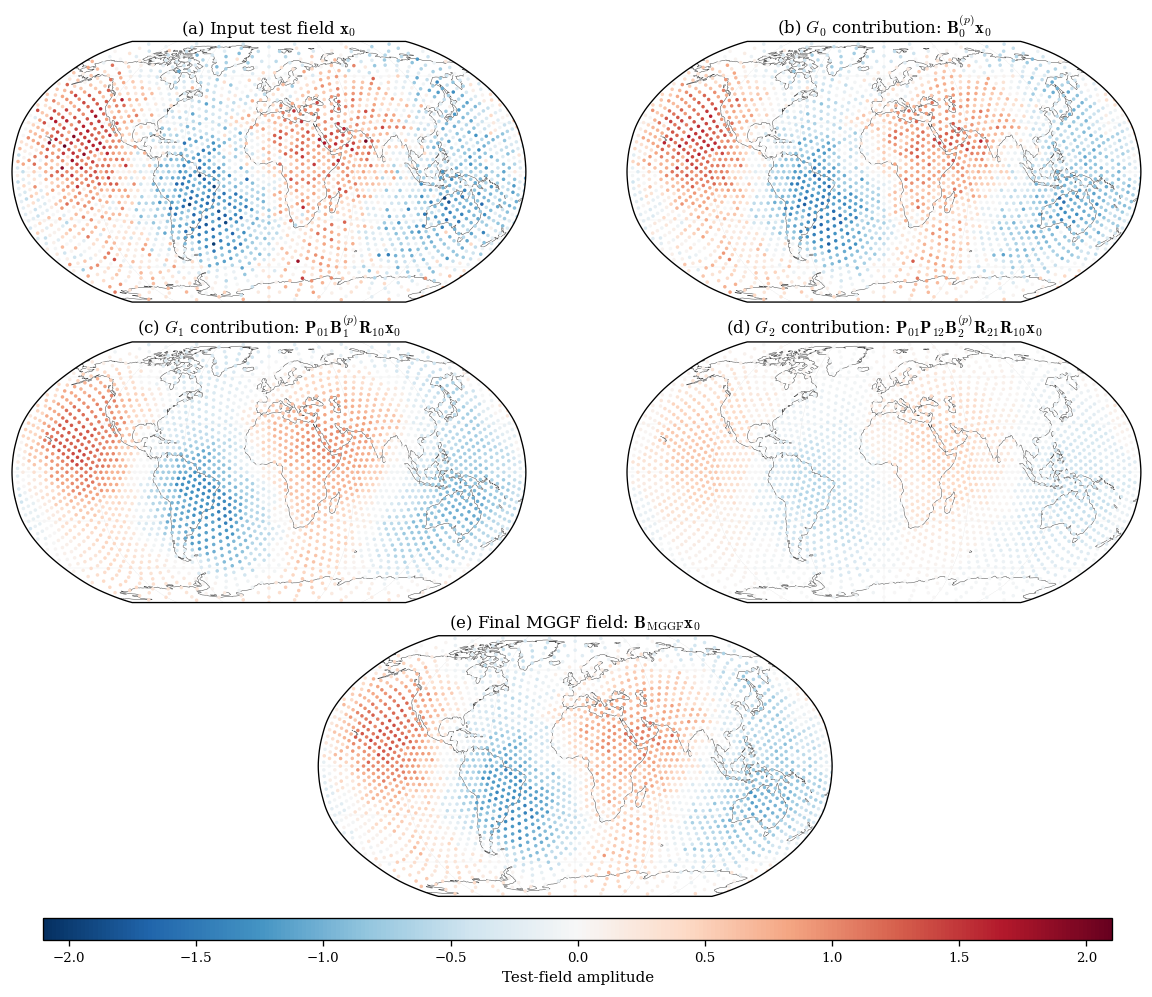

In [ ]:
# ============================================================
# Figure 8: final S1 area-compatible repeated-resolvent MGGF
#
# Multilevel smoothing with
#
#     B_l^(p) = [I + (mu_l/p) L_A,l]^(-p),   p = 5
#
# where
#
#     L_A,l = Ahat_l^(-1) Q_l
#     Q_l   = diag(W_l 1) - W_l
#
# and W_l is obtained by symmetric diagonal Sinkhorn balancing
# of the unweighted graph adjacency matrix.
#
# Panels:
#   (a) input field on G0
#   (b) G0 Graph Filter contribution
#   (c) G1 contribution transferred back to G0
#   (d) G2 contribution transferred back to G0
#   (e) final weighted MGGF field
#
# This version implements the final S1 formulation used in the paper.
# ============================================================

# Run once in a new Colab notebook if Cartopy is unavailable:
!pip -q install cartopy

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs


# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = f"{PROJECT_ROOT}/grid"

PAPER_FIG_DIR = f"{PROJECT_ROOT}/paper_figures"
os.makedirs(PAPER_FIG_DIR, exist_ok=True)

G0_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub4.npz"
G1_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub3.npz"
G2_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub2.npz"

COMM_FILE = (
    f"{GRID_DIR}/global_hex_ico_geometric_communication_v0.npz"
)

OUT_DATA_FILE = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5_data.npz"
)

OUT_PNG = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5.png"
)

OUT_PDF = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5.pdf"
)


# ============================================================
# Filter parameters
# ============================================================

P_ORDER = 5

MU0 = 0.50
MU1 = 2.00
MU2 = 6.00

W0 = 1.00
W1 = 0.50
W2 = 0.25

WSUM = W0 + W1 + W2

RNG_SEED = 1234

# Keep exactly the same noise amplitude as in the original experiment.
NOISE_AMPLITUDE = 0.35


# ============================================================
# Sinkhorn parameters
# ============================================================

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000


# ============================================================
# Publication settings
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "mathtext.fontset": "cm",
})


# ============================================================
# Utilities
# ============================================================

def load_grid(path):
    """Load one graph generation."""

    if not os.path.exists(path):
        raise FileNotFoundError(f"Grid file not found:\n{path}")

    g = np.load(path, allow_pickle=True)

    xyz = g["cell_center_xyz"].astype(np.float64)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]

    lon = g["cell_center_lon"].astype(np.float64)
    lat = g["cell_center_lat"].astype(np.float64)
    area = g["cell_area"].astype(np.float64)

    # Convert radians to degrees when necessary.
    if np.max(np.abs(lon)) <= 2.0 * np.pi + 1.0e-6:
        lon = np.rad2deg(lon)
        lat = np.rad2deg(lat)

    return {
        "xyz": xyz,
        "lon": lon,
        "lat": lat,
        "area": area,
        "dual_cells": g["dual_cells"],
        "ncells": len(area),
    }


def build_PR(parent, area_f, area_c):
    """
    Construct piecewise-constant prolongation P and conservative
    area-weighted restriction R.

    P maps coarse values to all associated fine cells.

    R maps fine values to coarse cells using finite-volume
    area weighting:

        R = A_c^{-1} P^T A_f
    """

    parent = np.asarray(parent, dtype=np.int64)

    nf = len(parent)
    nc = len(area_c)

    if np.min(parent) < 0 or np.max(parent) >= nc:
        raise ValueError(
            "Parent map contains an invalid coarse-cell index."
        )

    rows = np.arange(nf, dtype=np.int64)
    cols = parent
    vals = np.ones(nf, dtype=np.float64)

    P = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(nf, nc)
    ).tocsr()

    R = (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()

    return P, R


def build_neighbors_from_dual_cells(dual_cells):
    """Construct cell-neighbor lists from shared polygon edges."""

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):
        poly = np.asarray(poly, dtype=np.int64)

        for k in range(len(poly)):
            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])

            key = tuple(sorted((a, b)))
            edge_to_cells.setdefault(key, []).append(ci)

    neighbors = [set() for _ in range(len(dual_cells))]

    for cells in edge_to_cells.values():
        if len(cells) == 2:
            i, j = cells
            neighbors[i].add(j)
            neighbors[j].add(i)

    return [sorted(nbrs) for nbrs in neighbors]


def build_symmetric_adjacency(dual_cells):
    """
    Construct the symmetric unweighted nearest-neighbor
    graph adjacency matrix.
    """

    neighbors = build_neighbors_from_dual_cells(dual_cells)
    n = len(neighbors)

    rows = []
    cols = []

    for i, nbrs in enumerate(neighbors):
        for j in nbrs:
            rows.append(i)
            cols.append(j)

    vals = np.ones(len(rows), dtype=np.float64)

    adjacency = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()

    # Remove any accidental diagonal entries.
    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()

    # Enforce exact symmetry.
    adjacency = (0.5 * (adjacency + adjacency.T)).tocsr()
    adjacency.eliminate_zeros()

    degree = np.asarray(
        adjacency.sum(axis=1)
    ).ravel()

    return adjacency, degree


def build_area_compatible_laplacian(
    dual_cells,
    area,
    sinkhorn_tol=SINKHORN_TOL,
    sinkhorn_maxiter=SINKHORN_MAXITER,
):
    """
    Construct the final S1 area-compatible graph Laplacian

        L_A = Ahat^{-1} Q,

    where

        Q = diag(W 1) - W,

    and W is obtained by symmetric diagonal balancing of the
    unweighted graph adjacency matrix:

        W = diag(s) Adj diag(s).

    The target row sums are the normalized finite-volume areas

        ahat_i = A_i / mean(A).

    Thus, before any optional overall scalar normalization,

        W 1 = ahat.

    The resulting operator satisfies

        Ahat L_A = L_A^T Ahat

    and

        L_A 1 = 0.
    """

    adjacency, degree = build_symmetric_adjacency(dual_cells)
    n = adjacency.shape[0]

    # ------------------------------------------------------------
    # Dimensionless normalized cell areas
    # ------------------------------------------------------------

    area = np.asarray(area, dtype=np.float64)

    if np.any(area <= 0.0):
        raise ValueError("All finite-volume cell areas must be positive.")

    ahat = area / np.mean(area)

    # ------------------------------------------------------------
    # Symmetric Sinkhorn / diagonal balancing
    #
    # Seek
    #
    #     W = diag(s) Adj diag(s)
    #
    # such that
    #
    #     W 1 = ahat.
    #
    # The fixed-point relation is
    #
    #     s_i (Adj s)_i = ahat_i.
    #
    # A geometrically damped symmetric iteration is used:
    #
    #     s_new = sqrt(s * ahat/(Adj s)).
    #
    # ------------------------------------------------------------

    s = np.ones(n, dtype=np.float64)

    converged = False
    rel_error = np.inf

    for iteration in range(sinkhorn_maxiter):

        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(
                "Invalid adjacency encountered during "
                "symmetric balancing."
            )

        s_new = np.sqrt(
            s * ahat / adjacency_s
        )

        row_sum_new = s_new * (adjacency @ s_new)

        rel_error = np.max(
            np.abs(row_sum_new - ahat)
            / np.maximum(ahat, 1.0e-300)
        )

        s = s_new

        if rel_error < sinkhorn_tol:
            converged = True
            break

    if not converged:
        raise RuntimeError(
            "Symmetric Sinkhorn balancing failed to converge. "
            f"Final relative error = {rel_error:.3e}"
        )

    # ------------------------------------------------------------
    # Symmetric balanced edge-conductance matrix
    # ------------------------------------------------------------

    Wedge = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    Wedge = (0.5 * (Wedge + Wedge.T)).tocsr()
    Wedge.eliminate_zeros()

    row_sum = np.asarray(
        Wedge @ np.ones(n, dtype=np.float64)
    ).ravel()

    # ------------------------------------------------------------
    # Symmetric graph stiffness matrix
    #
    #     Q = diag(W 1) - W
    # ------------------------------------------------------------

    Q = (
        sp.diags(row_sum)
        - Wedge
    ).tocsr()

    # ------------------------------------------------------------
    # Area-compatible graph Laplacian
    #
    #     L_A = Ahat^{-1} Q
    # ------------------------------------------------------------

    L_A = (
        sp.diags(1.0 / ahat)
        @ Q
    ).tocsr()

    # ------------------------------------------------------------
    # Operator diagnostics
    # ------------------------------------------------------------

    ones = np.ones(n, dtype=np.float64)
    Ahat = sp.diags(ahat)

    balance_error = np.max(
        np.abs(row_sum - ahat)
        / np.maximum(ahat, 1.0e-300)
    )

    constant_error = np.max(
        np.abs(L_A @ ones)
    )

    weighted_matrix = Ahat @ L_A

    weighted_adjoint_error = (
        spla.norm(
            weighted_matrix
            - L_A.T @ Ahat
        )
        /
        max(
            spla.norm(weighted_matrix),
            1.0e-300
        )
    )

    W_symmetry_error = (
        spla.norm(Wedge - Wedge.T)
        /
        max(spla.norm(Wedge), 1.0e-300)
    )

    Q_symmetry_error = (
        spla.norm(Q - Q.T)
        /
        max(spla.norm(Q), 1.0e-300)
    )

    print(f"  cells                      : {n}")
    print(
        f"  degree range               : "
        f"{degree.min():.0f} "
        f"{degree.mean():.6f} "
        f"{degree.max():.0f}"
    )
    print(
        f"  Sinkhorn iterations        : {iteration + 1}"
    )
    print(
        f"  balance relative error     : {balance_error:.3e}"
    )
    print(
        f"  W symmetry relative error  : {W_symmetry_error:.3e}"
    )
    print(
        f"  Q symmetry relative error  : {Q_symmetry_error:.3e}"
    )
    print(
        f"  constant-null error        : {constant_error:.3e}"
    )
    print(
        f"  weighted-adjoint rel error : {weighted_adjoint_error:.3e}"
    )

    return L_A, degree, Wedge, Q, ahat


def graph_filter_apply(L_A, mu, p, x):
    """
    Apply the repeated-resolvent Graph Filter

        B^(p) = [I + (mu/p) L_A]^(-p)

    to x.
    """

    system = (
        sp.eye(L_A.shape[0], format="csr")
        + (mu / float(p)) * L_A
    )

    solve = spla.factorized(system.tocsc())

    y = np.asarray(x, dtype=np.float64).copy()

    for _ in range(p):
        y = solve(y)

    return y


def area_integral(x, area):
    """Finite-volume area-weighted integral."""

    return np.sum(area * x)


def area_mean(x, area):
    """Area-weighted global mean."""

    return area_integral(x, area) / np.sum(area)


def area_std(x, area):
    """Area-weighted standard deviation."""

    mean = area_mean(x, area)

    return np.sqrt(
        np.sum(area * (x - mean) ** 2)
        / np.sum(area)
    )


def area_norm(x, area):
    """Area-weighted quadratic norm squared."""

    return np.sum(area * x * x)


def report_field(name, x, area):
    """Print compact field diagnostics."""

    print(
        f"{name:42s}"
        f" mean={area_mean(x, area):+.8e}"
        f" std={area_std(x, area):.8e}"
        f" min={np.min(x):+.8e}"
        f" max={np.max(x):+.8e}"
    )


def draw_map_panel(
    ax,
    grid,
    field,
    title,
    norm,
    cmap,
    point_size=4.5,
):
    """Draw one global field panel on a Robinson projection."""

    ax.set_global()

    ax.coastlines(
        linewidth=0.30,
        color="0.30"
    )

    ax.gridlines(
        linewidth=0.25,
        color="0.55",
        alpha=0.45,
        linestyle=":"
    )

    scatter = ax.scatter(
        grid["lon"],
        grid["lat"],
        c=field,
        s=point_size,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        linewidths=0.0,
        rasterized=True,
        zorder=2
    )

    ax.set_title(
        title,
        pad=5
    )

    return scatter


# ============================================================
# Load grids and communication maps
# ============================================================

G0 = load_grid(G0_FILE)
G1 = load_grid(G1_FILE)
G2 = load_grid(G2_FILE)

if not os.path.exists(COMM_FILE):
    raise FileNotFoundError(
        f"Communication file not found:\n{COMM_FILE}"
    )

comm = np.load(COMM_FILE, allow_pickle=True)

parent01 = comm["parent01"].astype(np.int64)
parent12 = comm["parent12"].astype(np.int64)

P01, R10 = build_PR(
    parent01,
    G0["area"],
    G1["area"]
)

P12, R21 = build_PR(
    parent12,
    G1["area"],
    G2["area"]
)

P02 = P01 @ P12
R20 = R21 @ R10

print("=" * 72)
print("GRID HIERARCHY")
print("=" * 72)

print(f"G0 cells: {G0['ncells']}")
print(f"G1 cells: {G1['ncells']}")
print(f"G2 cells: {G2['ncells']}")


# ============================================================
# Transfer-operator diagnostics
# ============================================================

print("\n" + "=" * 72)
print("TRANSFER-OPERATOR DIAGNOSTICS")
print("=" * 72)

ones0 = np.ones(G0["ncells"], dtype=np.float64)
ones1 = np.ones(G1["ncells"], dtype=np.float64)
ones2 = np.ones(G2["ncells"], dtype=np.float64)

R10_const_error = np.max(
    np.abs(R10 @ ones0 - ones1)
)

R21_const_error = np.max(
    np.abs(R21 @ ones1 - ones2)
)

P01_const_error = np.max(
    np.abs(P01 @ ones1 - ones0)
)

P12_const_error = np.max(
    np.abs(P12 @ ones2 - ones1)
)

print(
    f"R10 constant error          : {R10_const_error:.3e}"
)
print(
    f"R21 constant error          : {R21_const_error:.3e}"
)
print(
    f"P01 constant error          : {P01_const_error:.3e}"
)
print(
    f"P12 constant error          : {P12_const_error:.3e}"
)


# ============================================================
# Construct final S1 area-compatible graph operators
# ============================================================

print("\n" + "=" * 72)
print("FINAL S1 AREA-COMPATIBLE GRAPH OPERATORS")
print("=" * 72)

print("\nConstructing G0 operator")
L0, degree0, Wedge0, Q0, ahat0 = (
    build_area_compatible_laplacian(
        G0["dual_cells"],
        G0["area"]
    )
)

print("\nConstructing G1 operator")
L1, degree1, Wedge1, Q1, ahat1 = (
    build_area_compatible_laplacian(
        G1["dual_cells"],
        G1["area"]
    )
)

print("\nConstructing G2 operator")
L2, degree2, Wedge2, Q2, ahat2 = (
    build_area_compatible_laplacian(
        G2["dual_cells"],
        G2["area"]
    )
)


# ============================================================
# Construct the G0 test field
# ============================================================

rng = np.random.default_rng(RNG_SEED)

lon0_rad = np.deg2rad(G0["lon"])
lat0_rad = np.deg2rad(G0["lat"])

# Smooth large-scale component.
x_smooth = (
    np.sin(2.0 * lon0_rad) * np.cos(lat0_rad)
    + 0.35 * np.sin(3.0 * lat0_rad)
    + 0.20 * np.cos(
        3.0 * lon0_rad
        + 2.0 * lat0_rad
    )
)

# Spatially uncorrelated perturbation.
x_noise = rng.standard_normal(G0["ncells"])

# Remove its finite-volume area-weighted mean.
x_noise -= area_mean(
    x_noise,
    G0["area"]
)

# Combined test field.
x0 = x_smooth + NOISE_AMPLITUDE * x_noise

# Use a zero-area-mean test field.
x0 -= area_mean(
    x0,
    G0["area"]
)


# ============================================================
# Apply the three-level MGGF
# ============================================================

# Restrict the input field to coarse graph generations.
x1 = R10 @ x0
x2 = R20 @ x0

# Filter independently on each graph generation.
y0_from0 = graph_filter_apply(
    L0,
    MU0,
    P_ORDER,
    x0
)

y1_filtered = graph_filter_apply(
    L1,
    MU1,
    P_ORDER,
    x1
)

y2_filtered = graph_filter_apply(
    L2,
    MU2,
    P_ORDER,
    x2
)

# Return coarse-generation contributions to G0.
y0_from1 = P01 @ y1_filtered
y0_from2 = P02 @ y2_filtered

# Weighted MGGF combination.
y0_MGGF = (
    W0 * y0_from0
    + W1 * y0_from1
    + W2 * y0_from2
) / WSUM


# ============================================================
# Quantitative diagnostics
# ============================================================

mean_input = area_mean(
    x0,
    G0["area"]
)

mean_g0 = area_mean(
    y0_from0,
    G0["area"]
)

mean_g1 = area_mean(
    y0_from1,
    G0["area"]
)

mean_g2 = area_mean(
    y0_from2,
    G0["area"]
)

mean_mggf = area_mean(
    y0_MGGF,
    G0["area"]
)

integral_input = area_integral(
    x0,
    G0["area"]
)

integral_g0 = area_integral(
    y0_from0,
    G0["area"]
)

integral_g1 = area_integral(
    y0_from1,
    G0["area"]
)

integral_g2 = area_integral(
    y0_from2,
    G0["area"]
)

integral_mggf = area_integral(
    y0_MGGF,
    G0["area"]
)

std_input = area_std(
    x0,
    G0["area"]
)

std_g0 = area_std(
    y0_from0,
    G0["area"]
)

std_g1 = area_std(
    y0_from1,
    G0["area"]
)

std_g2 = area_std(
    y0_from2,
    G0["area"]
)

std_mggf = area_std(
    y0_MGGF,
    G0["area"]
)

ratio_g0 = std_g0 / std_input
ratio_mggf = std_mggf / std_input

norm_input = area_norm(
    x0,
    G0["area"]
)

norm_g0 = area_norm(
    y0_from0,
    G0["area"]
)

norm_mggf = area_norm(
    y0_MGGF,
    G0["area"]
)

mean_error_g0 = abs(
    mean_g0 - mean_input
)

mean_error_g1 = abs(
    mean_g1 - mean_input
)

mean_error_g2 = abs(
    mean_g2 - mean_input
)

mean_error_mggf = abs(
    mean_mggf - mean_input
)

integral_error_g0 = abs(
    integral_g0 - integral_input
)

integral_error_g1 = abs(
    integral_g1 - integral_input
)

integral_error_g2 = abs(
    integral_g2 - integral_input
)

integral_error_mggf = abs(
    integral_mggf - integral_input
)


# ============================================================
# Print diagnostics
# ============================================================

print("\n" + "=" * 72)
print("FIELD DIAGNOSTICS")
print("=" * 72)

report_field(
    "Input field x0",
    x0,
    G0["area"]
)

report_field(
    "G0 contribution B0 x0",
    y0_from0,
    G0["area"]
)

report_field(
    "G1 contribution P01 B1 R10 x0",
    y0_from1,
    G0["area"]
)

report_field(
    "G2 contribution P02 B2 R20 x0",
    y0_from2,
    G0["area"]
)

report_field(
    "Final MGGF field",
    y0_MGGF,
    G0["area"]
)

print("\nStandard-deviation ratios:")

print(
    "std(B0 x0) / std(x0)       =",
    ratio_g0
)

print(
    "std(MGGF x0) / std(x0)     =",
    ratio_mggf
)


print("\nArea-weighted mean preservation:")

print(
    "mean(input)                 =",
    mean_input
)

print(
    "mean(G0 contribution)       =",
    mean_g0
)

print(
    "mean(G1 contribution)       =",
    mean_g1
)

print(
    "mean(G2 contribution)       =",
    mean_g2
)

print(
    "mean(MGGF input)            =",
    mean_mggf
)


print("\nAbsolute mean errors:")

print(
    "|G0-input|                  =",
    mean_error_g0
)

print(
    "|G1-input|                  =",
    mean_error_g1
)

print(
    "|G2-input|                  =",
    mean_error_g2
)

print(
    "|MGGF-input|                =",
    mean_error_mggf
)


print("\nArea-integral preservation:")

print(
    "Integral(input)             =",
    integral_input
)

print(
    "Integral(G0 contribution)   =",
    integral_g0
)

print(
    "Integral(G1 contribution)   =",
    integral_g1
)

print(
    "Integral(G2 contribution)   =",
    integral_g2
)

print(
    "Integral(MGGF)              =",
    integral_mggf
)


print("\nAbsolute area-integral errors:")

print(
    "|G0-input|                  =",
    integral_error_g0
)

print(
    "|G1-input|                  =",
    integral_error_g1
)

print(
    "|G2-input|                  =",
    integral_error_g2
)

print(
    "|MGGF-input|                =",
    integral_error_mggf
)


print("\nArea-weighted quadratic norms:")

print(
    "<x0,x0>_A                  =",
    norm_input
)

print(
    "<B0x0,B0x0>_A              =",
    norm_g0
)

print(
    "<MGGF x0,MGGF x0>_A        =",
    norm_mggf
)


# ============================================================
# Shared color normalization
# ============================================================

fields = [
    x0,
    y0_from0,
    y0_from1,
    y0_from2,
    y0_MGGF,
]

# Use one symmetric scale for all five maps.
vmax = max(
    np.max(np.abs(field))
    for field in fields
)

norm = mcolors.TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0.0,
    vmax=vmax
)

cmap = "RdBu_r"


# ============================================================
# Publication-quality Figure 8
# ============================================================

projection = ccrs.Robinson()

fig = plt.figure(
    figsize=(10.0, 8.2),
    constrained_layout=True
)

grid_spec = fig.add_gridspec(
    nrows=3,
    ncols=4,
    height_ratios=[1.0, 1.0, 1.0],
    width_ratios=[1.0, 1.0, 1.0, 1.0]
)

ax_a = fig.add_subplot(
    grid_spec[0, 0:2],
    projection=projection
)

ax_b = fig.add_subplot(
    grid_spec[0, 2:4],
    projection=projection
)

ax_c = fig.add_subplot(
    grid_spec[1, 0:2],
    projection=projection
)

ax_d = fig.add_subplot(
    grid_spec[1, 2:4],
    projection=projection
)

ax_e = fig.add_subplot(
    grid_spec[2, 1:3],
    projection=projection
)


scatter = draw_map_panel(
    ax_a,
    G0,
    x0,
    r"(a) Input test field $\mathbf{x}_0$",
    norm,
    cmap
)

draw_map_panel(
    ax_b,
    G0,
    y0_from0,
    r"(b) $G_0$ contribution: "
    r"$\mathbf{B}_0^{(p)}\mathbf{x}_0$",
    norm,
    cmap
)

draw_map_panel(
    ax_c,
    G0,
    y0_from1,
    r"(c) $G_1$ contribution: "
    r"$\mathbf{P}_{01}\mathbf{B}_1^{(p)}"
    r"\mathbf{R}_{10}\mathbf{x}_0$",
    norm,
    cmap
)

draw_map_panel(
    ax_d,
    G0,
    y0_from2,
    r"(d) $G_2$ contribution: "
    r"$\mathbf{P}_{01}\mathbf{P}_{12}"
    r"\mathbf{B}_2^{(p)}\mathbf{R}_{21}"
    r"\mathbf{R}_{10}\mathbf{x}_0$",
    norm,
    cmap
)

draw_map_panel(
    ax_e,
    G0,
    y0_MGGF,
    r"(e) Final MGGF field: "
    r"$\mathbf{B}_{\mathrm{MGGF}}\mathbf{x}_0$",
    norm,
    cmap
)


# ============================================================
# Shared horizontal colorbar
# ============================================================

colorbar = fig.colorbar(
    scatter,
    ax=[ax_a, ax_b, ax_c, ax_d, ax_e],
    orientation="horizontal",
    fraction=0.025,
    pad=0.025,
    aspect=50
)

colorbar.set_label(
    "Test-field amplitude",
    fontsize=9
)

colorbar.ax.tick_params(
    labelsize=8
)


# ============================================================
# Save figure and data
# ============================================================

fig.savefig(
    OUT_PNG,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)

np.savez(
    OUT_DATA_FILE,

    # Fields
    x0=x0,
    x_smooth=x_smooth,
    x_noise=x_noise,
    y0_from0=y0_from0,
    y0_from1=y0_from1,
    y0_from2=y0_from2,
    y0_MGGF=y0_MGGF,

    # Filter parameters
    p=P_ORDER,
    mu0=MU0,
    mu1=MU1,
    mu2=MU2,
    w0=W0,
    w1=W1,
    w2=W2,

    # Experiment parameters
    noise_amplitude=NOISE_AMPLITUDE,

    # Standard deviations
    std_input=std_input,
    std_g0=std_g0,
    std_g1=std_g1,
    std_g2=std_g2,
    std_mggf=std_mggf,

    # Ratios
    ratio_g0=ratio_g0,
    ratio_mggf=ratio_mggf,

    # Means
    mean_input=mean_input,
    mean_g0=mean_g0,
    mean_g1=mean_g1,
    mean_g2=mean_g2,
    mean_mggf=mean_mggf,

    # Mean errors
    mean_error_g0=mean_error_g0,
    mean_error_g1=mean_error_g1,
    mean_error_g2=mean_error_g2,
    mean_error_mggf=mean_error_mggf,

    # Integrals
    integral_input=integral_input,
    integral_g0=integral_g0,
    integral_g1=integral_g1,
    integral_g2=integral_g2,
    integral_mggf=integral_mggf,

    # Integral errors
    integral_error_g0=integral_error_g0,
    integral_error_g1=integral_error_g1,
    integral_error_g2=integral_error_g2,
    integral_error_mggf=integral_error_mggf,

    # Quadratic norms
    norm_input=norm_input,
    norm_g0=norm_g0,
    norm_mggf=norm_mggf,

    # S1 normalized areas
    ahat0=ahat0,
    ahat1=ahat1,
    ahat2=ahat2,
)


print("\n" + "=" * 72)
print("OUTPUT")
print("=" * 72)

print("Saved PNG :", OUT_PNG)
print("Saved PDF :", OUT_PDF)
print("Saved data:", OUT_DATA_FILE)

plt.show()

# New Figure 8 v2

GRID HIERARCHY
G0 cells: 2562
G1 cells: 642
G2 cells: 162

COARSE-AREA CONSISTENCY
G0 total geometric area     = 510099699070761.6
G1 total geometric area     = 510099699070761.6
G2 total geometric area     = 510099699070761.7
G0 total hierarchy area     = 510099699070761.6
G1 total hierarchy area     = 510099699070761.6
G2 total hierarchy area     = 510099699070761.56
G1 max relative difference  = 3.0098890189292664
G2 max relative difference  = 7.0530485804235195

TRANSFER-OPERATOR DIAGNOSTICS
R10 constant error          : 3.331e-16
R21 constant error          : 3.331e-16
R20 constant error          : 4.441e-16
P01 constant error          : 0.000e+00
P12 constant error          : 0.000e+00
P02 constant error          : 0.000e+00
P01/R10 weighted-adjoint err: 8.128e-17
P12/R21 weighted-adjoint err: 6.736e-17

FINAL S1 AREA-COMPATIBLE GRAPH OPERATORS

Constructing G0 operator
  cells                      : 2562
  degree range               : 5 5.995316 6
  Sinkhorn iterations        : 

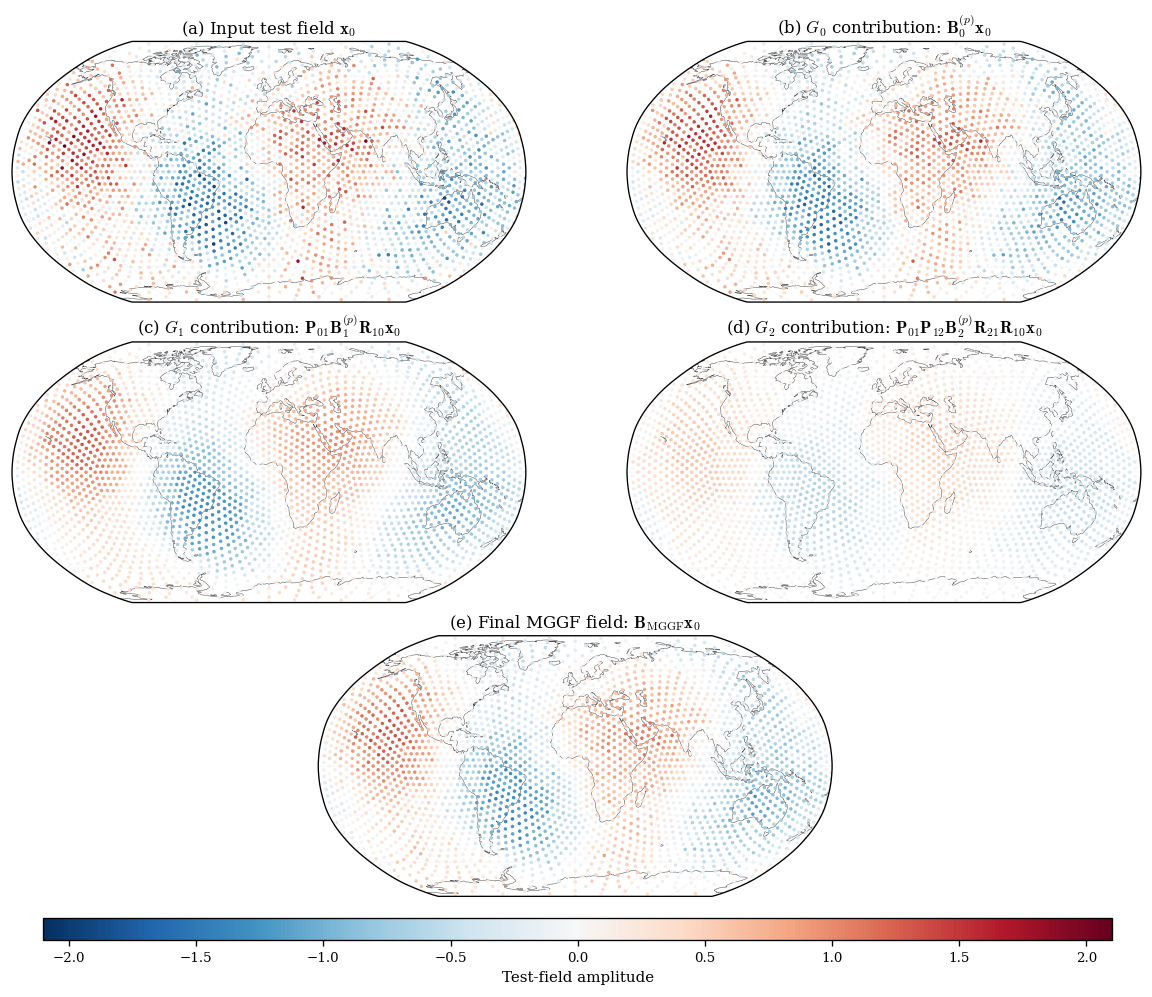

In [ ]:
# ============================================================
# Figure 8: final S1 area-compatible repeated-resolvent MGGF
#
# CONSERVATIVE-HIERARCHY VERSION
#
# Single-level Graph Filter:
#
#     B_l^(p) = [I + (mu_l/p) L_A,l]^(-p),   p = 5
#
# with
#
#     L_A,l = Ahat_l^(-1) Q_l
#     Q_l   = diag(W_l 1) - W_l
#
# W_l is obtained by symmetric diagonal balancing of the
# unweighted graph adjacency matrix.
#
# Multilevel hierarchy:
#
#     A_1 = P_01^T A_0
#     A_2 = P_12^T A_1
#
# so that restriction
#
#     R = A_c^(-1) P^T A_f
#
# preserves constants and the finite-volume area integral exactly.
#
# Panels:
#   (a) input field on G0
#   (b) G0 Graph Filter contribution
#   (c) G1 contribution transferred back to G0
#   (d) G2 contribution transferred back to G0
#   (e) final weighted MGGF field
#
# ============================================================

# Run once in a new Colab notebook if Cartopy is unavailable:
!pip -q install cartopy

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs


# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = f"{PROJECT_ROOT}/grid"

PAPER_FIG_DIR = f"{PROJECT_ROOT}/paper_figures"
os.makedirs(PAPER_FIG_DIR, exist_ok=True)

G0_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub4.npz"
G1_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub3.npz"
G2_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub2.npz"

COMM_FILE = (
    f"{GRID_DIR}/global_hex_ico_geometric_communication_v0.npz"
)

OUT_DATA_FILE = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5_conservative_data.npz"
)

OUT_PNG = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5_conservative.png"
)

OUT_PDF = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5_conservative.pdf"
)


# ============================================================
# Filter parameters
# ============================================================

P_ORDER = 5

MU0 = 0.50
MU1 = 2.00
MU2 = 6.00

W0 = 1.00
W1 = 0.50
W2 = 0.25

WSUM = W0 + W1 + W2

RNG_SEED = 1234
NOISE_AMPLITUDE = 0.35


# ============================================================
# Sinkhorn parameters
# ============================================================

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000


# ============================================================
# Publication settings
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "mathtext.fontset": "cm",
})


# ============================================================
# Grid utilities
# ============================================================

def load_grid(path):
    """Load one graph generation."""

    if not os.path.exists(path):
        raise FileNotFoundError(f"Grid file not found:\n{path}")

    g = np.load(path, allow_pickle=True)

    xyz = g["cell_center_xyz"].astype(np.float64)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]

    lon = g["cell_center_lon"].astype(np.float64)
    lat = g["cell_center_lat"].astype(np.float64)
    area = g["cell_area"].astype(np.float64)

    if np.max(np.abs(lon)) <= 2.0 * np.pi + 1.0e-6:
        lon = np.rad2deg(lon)
        lat = np.rad2deg(lat)

    return {
        "xyz": xyz,
        "lon": lon,
        "lat": lat,
        "area": area,
        "dual_cells": g["dual_cells"],
        "ncells": len(area),
    }


def build_prolongation(parent, nf, nc):
    """
    Construct piecewise-constant prolongation P.

    Each fine cell receives the value of its unique coarse parent.
    """

    parent = np.asarray(parent, dtype=np.int64)

    if len(parent) != nf:
        raise ValueError("Parent-map length is inconsistent.")

    if np.min(parent) < 0 or np.max(parent) >= nc:
        raise ValueError("Parent map contains invalid indices.")

    rows = np.arange(nf, dtype=np.int64)
    cols = parent
    vals = np.ones(nf, dtype=np.float64)

    P = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(nf, nc)
    ).tocsr()

    return P


def aggregate_coarse_area(P, area_f):
    """
    Construct coarse finite-volume measures by conservative
    aggregation:

        A_c = P^T A_f.
    """

    return np.asarray(
        P.T @ np.asarray(area_f, dtype=np.float64)
    ).ravel()


def build_restriction(P, area_f, area_c):
    """
    Construct area-weighted restriction

        R = A_c^{-1} P^T A_f.

    If A_c = P^T A_f, this preserves both constants and the
    finite-volume area integral exactly up to floating-point error.
    """

    return (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()


def relative_area_difference(a, b):
    """
    Maximum pointwise relative difference between two positive
    area arrays, normalized by the first argument.
    """

    return np.max(
        np.abs(a - b)
        / np.maximum(np.abs(a), 1.0e-300)
    )


# ============================================================
# Graph utilities
# ============================================================

def build_neighbors_from_dual_cells(dual_cells):
    """Construct cell-neighbor lists from shared polygon edges."""

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):

        poly = np.asarray(poly, dtype=np.int64)

        for k in range(len(poly)):

            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])

            key = tuple(sorted((a, b)))

            edge_to_cells.setdefault(
                key, []
            ).append(ci)

    neighbors = [
        set()
        for _ in range(len(dual_cells))
    ]

    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            neighbors[i].add(j)
            neighbors[j].add(i)

    return [
        sorted(nbrs)
        for nbrs in neighbors
    ]


def build_symmetric_adjacency(dual_cells):
    """
    Construct symmetric unweighted nearest-neighbor adjacency.
    """

    neighbors = build_neighbors_from_dual_cells(
        dual_cells
    )

    n = len(neighbors)

    rows = []
    cols = []

    for i, nbrs in enumerate(neighbors):

        for j in nbrs:

            rows.append(i)
            cols.append(j)

    vals = np.ones(
        len(rows),
        dtype=np.float64
    )

    adjacency = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()

    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()

    adjacency = (
        0.5 * (adjacency + adjacency.T)
    ).tocsr()

    adjacency.eliminate_zeros()

    degree = np.asarray(
        adjacency.sum(axis=1)
    ).ravel()

    return adjacency, degree


# ============================================================
# Final S1 area-compatible graph operator
# ============================================================

def build_area_compatible_laplacian(
    dual_cells,
    area,
    sinkhorn_tol=SINKHORN_TOL,
    sinkhorn_maxiter=SINKHORN_MAXITER,
):
    """
    Construct final S1 area-compatible graph Laplacian:

        L_A = Ahat^{-1} Q

    with

        Q = diag(W 1) - W,

    where

        W = diag(s) Adj diag(s)

    is symmetric and balanced so that

        W 1 = ahat,

    and

        ahat_i = A_i / mean(A).
    """

    adjacency, degree = (
        build_symmetric_adjacency(
            dual_cells
        )
    )

    n = adjacency.shape[0]

    area = np.asarray(
        area,
        dtype=np.float64
    )

    if np.any(area <= 0.0):
        raise ValueError(
            "All cell areas must be positive."
        )

    ahat = area / np.mean(area)

    # --------------------------------------------------------
    # Symmetric diagonal balancing
    # --------------------------------------------------------

    s = np.ones(
        n,
        dtype=np.float64
    )

    converged = False
    rel_error = np.inf

    for iteration in range(
        sinkhorn_maxiter
    ):

        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(
                "Invalid adjacency during balancing."
            )

        s_new = np.sqrt(
            s * ahat / adjacency_s
        )

        row_sum_new = (
            s_new
            * (adjacency @ s_new)
        )

        rel_error = np.max(
            np.abs(
                row_sum_new - ahat
            )
            /
            np.maximum(
                ahat,
                1.0e-300
            )
        )

        s = s_new

        if rel_error < sinkhorn_tol:

            converged = True
            break

    if not converged:

        raise RuntimeError(
            "Symmetric balancing failed to converge. "
            f"Final error = {rel_error:.3e}"
        )

    # --------------------------------------------------------
    # Balanced edge-conductance matrix
    # --------------------------------------------------------

    Wedge = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    Wedge = (
        0.5 * (Wedge + Wedge.T)
    ).tocsr()

    Wedge.eliminate_zeros()

    row_sum = np.asarray(
        Wedge @ np.ones(n)
    ).ravel()

    # --------------------------------------------------------
    # Symmetric graph stiffness matrix
    # --------------------------------------------------------

    Q = (
        sp.diags(row_sum)
        - Wedge
    ).tocsr()

    # --------------------------------------------------------
    # Area-compatible graph Laplacian
    # --------------------------------------------------------

    L_A = (
        sp.diags(1.0 / ahat)
        @ Q
    ).tocsr()

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    ones = np.ones(
        n,
        dtype=np.float64
    )

    Ahat = sp.diags(ahat)

    balance_error = np.max(
        np.abs(
            row_sum - ahat
        )
        /
        np.maximum(
            ahat,
            1.0e-300
        )
    )

    constant_error = np.max(
        np.abs(
            L_A @ ones
        )
    )

    W_symmetry_error = (
        spla.norm(
            Wedge - Wedge.T
        )
        /
        max(
            spla.norm(Wedge),
            1.0e-300
        )
    )

    Q_symmetry_error = (
        spla.norm(
            Q - Q.T
        )
        /
        max(
            spla.norm(Q),
            1.0e-300
        )
    )

    weighted_adjoint_error = (
        spla.norm(
            Ahat @ L_A
            - L_A.T @ Ahat
        )
        /
        max(
            spla.norm(
                Ahat @ L_A
            ),
            1.0e-300
        )
    )

    print(
        f"  cells                      : {n}"
    )

    print(
        f"  degree range               : "
        f"{degree.min():.0f} "
        f"{degree.mean():.6f} "
        f"{degree.max():.0f}"
    )

    print(
        f"  Sinkhorn iterations        : "
        f"{iteration + 1}"
    )

    print(
        f"  balance relative error     : "
        f"{balance_error:.3e}"
    )

    print(
        f"  W symmetry relative error  : "
        f"{W_symmetry_error:.3e}"
    )

    print(
        f"  Q symmetry relative error  : "
        f"{Q_symmetry_error:.3e}"
    )

    print(
        f"  constant-null error        : "
        f"{constant_error:.3e}"
    )

    print(
        f"  weighted-adjoint rel error : "
        f"{weighted_adjoint_error:.3e}"
    )

    return (
        L_A,
        degree,
        Wedge,
        Q,
        ahat
    )


# ============================================================
# Repeated-resolvent Graph Filter
# ============================================================

def graph_filter_apply(
    L_A,
    mu,
    p,
    x
):
    """
    Apply

        B^(p) = [I + (mu/p)L_A]^(-p).
    """

    system = (
        sp.eye(
            L_A.shape[0],
            format="csr"
        )
        +
        (mu / float(p)) * L_A
    )

    solve = spla.factorized(
        system.tocsc()
    )

    y = np.asarray(
        x,
        dtype=np.float64
    ).copy()

    for _ in range(p):

        y = solve(y)

    return y


# ============================================================
# Field diagnostics
# ============================================================

def area_integral(x, area):
    """Finite-volume area integral."""

    return np.sum(
        area * x
    )


def area_mean(x, area):
    """Finite-volume area-weighted mean."""

    return (
        area_integral(x, area)
        /
        np.sum(area)
    )


def area_std(x, area):
    """Area-weighted standard deviation."""

    mean = area_mean(
        x,
        area
    )

    return np.sqrt(
        np.sum(
            area * (x - mean) ** 2
        )
        /
        np.sum(area)
    )


def area_norm(x, area):
    """Area-weighted quadratic norm squared."""

    return np.sum(
        area * x * x
    )


def report_field(
    name,
    x,
    area
):
    """Print compact field diagnostics."""

    print(
        f"{name:42s}"
        f" mean={area_mean(x, area):+.8e}"
        f" std={area_std(x, area):.8e}"
        f" min={np.min(x):+.8e}"
        f" max={np.max(x):+.8e}"
    )


# ============================================================
# Plotting utility
# ============================================================

def draw_map_panel(
    ax,
    grid,
    field,
    title,
    norm,
    cmap,
    point_size=4.5,
):

    ax.set_global()

    ax.coastlines(
        linewidth=0.30,
        color="0.30"
    )

    ax.gridlines(
        linewidth=0.25,
        color="0.55",
        alpha=0.45,
        linestyle=":"
    )

    scatter = ax.scatter(
        grid["lon"],
        grid["lat"],
        c=field,
        s=point_size,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        linewidths=0.0,
        rasterized=True,
        zorder=2
    )

    ax.set_title(
        title,
        pad=5
    )

    return scatter


# ============================================================
# Load geometric grids
# ============================================================

G0 = load_grid(G0_FILE)
G1 = load_grid(G1_FILE)
G2 = load_grid(G2_FILE)

# Preserve independently generated geometric areas for diagnostics.
area0_geometric = G0["area"].copy()
area1_geometric = G1["area"].copy()
area2_geometric = G2["area"].copy()


# ============================================================
# Load parent maps
# ============================================================

if not os.path.exists(COMM_FILE):

    raise FileNotFoundError(
        f"Communication file not found:\n{COMM_FILE}"
    )

comm = np.load(
    COMM_FILE,
    allow_pickle=True
)

parent01 = comm[
    "parent01"
].astype(np.int64)

parent12 = comm[
    "parent12"
].astype(np.int64)


# ============================================================
# Construct piecewise-constant prolongation operators
# ============================================================

P01 = build_prolongation(
    parent01,
    G0["ncells"],
    G1["ncells"]
)

P12 = build_prolongation(
    parent12,
    G1["ncells"],
    G2["ncells"]
)

P02 = P01 @ P12


# ============================================================
# Construct CONSERVATIVE hierarchy areas
# ============================================================

# Finest level retains its actual finite-volume areas.
area0 = area0_geometric.copy()

# Coarse areas are defined recursively from the hierarchy.
area1 = aggregate_coarse_area(
    P01,
    area0
)

area2 = aggregate_coarse_area(
    P12,
    area1
)


print("=" * 72)
print("GRID HIERARCHY")
print("=" * 72)

print(f"G0 cells: {G0['ncells']}")
print(f"G1 cells: {G1['ncells']}")
print(f"G2 cells: {G2['ncells']}")


# ============================================================
# Compare geometric and hierarchy areas
# ============================================================

print("\n" + "=" * 72)
print("COARSE-AREA CONSISTENCY")
print("=" * 72)

print(
    "G0 total geometric area     =",
    np.sum(area0_geometric)
)

print(
    "G1 total geometric area     =",
    np.sum(area1_geometric)
)

print(
    "G2 total geometric area     =",
    np.sum(area2_geometric)
)

print(
    "G0 total hierarchy area     =",
    np.sum(area0)
)

print(
    "G1 total hierarchy area     =",
    np.sum(area1)
)

print(
    "G2 total hierarchy area     =",
    np.sum(area2)
)

print(
    "G1 max relative difference  =",
    relative_area_difference(
        area1,
        area1_geometric
    )
)

print(
    "G2 max relative difference  =",
    relative_area_difference(
        area2,
        area2_geometric
    )
)


# ============================================================
# Use conservative hierarchy areas from this point onward
# ============================================================

G0["area"] = area0
G1["area"] = area1
G2["area"] = area2


# ============================================================
# Construct conservative restrictions
# ============================================================

R10 = build_restriction(
    P01,
    G0["area"],
    G1["area"]
)

R21 = build_restriction(
    P12,
    G1["area"],
    G2["area"]
)

R20 = R21 @ R10


# ============================================================
# Transfer diagnostics
# ============================================================

print("\n" + "=" * 72)
print("TRANSFER-OPERATOR DIAGNOSTICS")
print("=" * 72)

ones0 = np.ones(
    G0["ncells"],
    dtype=np.float64
)

ones1 = np.ones(
    G1["ncells"],
    dtype=np.float64
)

ones2 = np.ones(
    G2["ncells"],
    dtype=np.float64
)

print(
    "R10 constant error          : "
    f"{np.max(np.abs(R10 @ ones0 - ones1)):.3e}"
)

print(
    "R21 constant error          : "
    f"{np.max(np.abs(R21 @ ones1 - ones2)):.3e}"
)

print(
    "R20 constant error          : "
    f"{np.max(np.abs(R20 @ ones0 - ones2)):.3e}"
)

print(
    "P01 constant error          : "
    f"{np.max(np.abs(P01 @ ones1 - ones0)):.3e}"
)

print(
    "P12 constant error          : "
    f"{np.max(np.abs(P12 @ ones2 - ones1)):.3e}"
)

print(
    "P02 constant error          : "
    f"{np.max(np.abs(P02 @ ones2 - ones0)):.3e}"
)


# Weighted-adjoint diagnostics for transfers.

A0 = sp.diags(G0["area"])
A1 = sp.diags(G1["area"])
A2 = sp.diags(G2["area"])

adjoint01_error = (
    spla.norm(
        A0 @ P01
        - R10.T @ A1
    )
    /
    max(
        spla.norm(A0 @ P01),
        1.0e-300
    )
)

adjoint12_error = (
    spla.norm(
        A1 @ P12
        - R21.T @ A2
    )
    /
    max(
        spla.norm(A1 @ P12),
        1.0e-300
    )
)

print(
    "P01/R10 weighted-adjoint err: "
    f"{adjoint01_error:.3e}"
)

print(
    "P12/R21 weighted-adjoint err: "
    f"{adjoint12_error:.3e}"
)


# ============================================================
# Construct final S1 operators on each hierarchy generation
# ============================================================

print("\n" + "=" * 72)
print("FINAL S1 AREA-COMPATIBLE GRAPH OPERATORS")
print("=" * 72)

print("\nConstructing G0 operator")

L0, degree0, Wedge0, Q0, ahat0 = (
    build_area_compatible_laplacian(
        G0["dual_cells"],
        G0["area"]
    )
)

print("\nConstructing G1 operator")

L1, degree1, Wedge1, Q1, ahat1 = (
    build_area_compatible_laplacian(
        G1["dual_cells"],
        G1["area"]
    )
)

print("\nConstructing G2 operator")

L2, degree2, Wedge2, Q2, ahat2 = (
    build_area_compatible_laplacian(
        G2["dual_cells"],
        G2["area"]
    )
)


# ============================================================
# Construct the G0 test field
# ============================================================

rng = np.random.default_rng(
    RNG_SEED
)

lon0_rad = np.deg2rad(
    G0["lon"]
)

lat0_rad = np.deg2rad(
    G0["lat"]
)

# Smooth large-scale component.
x_smooth = (
    np.sin(
        2.0 * lon0_rad
    )
    * np.cos(lat0_rad)
    + 0.35
    * np.sin(
        3.0 * lat0_rad
    )
    + 0.20
    * np.cos(
        3.0 * lon0_rad
        + 2.0 * lat0_rad
    )
)

# Spatially uncorrelated perturbation.
x_noise = rng.standard_normal(
    G0["ncells"]
)

x_noise -= area_mean(
    x_noise,
    G0["area"]
)

# Combined test field.
x0 = (
    x_smooth
    + NOISE_AMPLITUDE * x_noise
)

# Remove area-weighted global mean.
x0 -= area_mean(
    x0,
    G0["area"]
)


# ============================================================
# Apply three-level MGGF
# ============================================================

# Restrict to coarse graph generations.
x1 = R10 @ x0
x2 = R20 @ x0

# Apply Graph Filter independently on each generation.
y0_from0 = graph_filter_apply(
    L0,
    MU0,
    P_ORDER,
    x0
)

y1_filtered = graph_filter_apply(
    L1,
    MU1,
    P_ORDER,
    x1
)

y2_filtered = graph_filter_apply(
    L2,
    MU2,
    P_ORDER,
    x2
)

# Prolong coarse contributions back to G0.
y0_from1 = (
    P01 @ y1_filtered
)

y0_from2 = (
    P02 @ y2_filtered
)

# Weighted MGGF.
y0_MGGF = (
    W0 * y0_from0
    + W1 * y0_from1
    + W2 * y0_from2
) / WSUM


# ============================================================
# Field diagnostics
# ============================================================

mean_input = area_mean(
    x0,
    G0["area"]
)

mean_g0 = area_mean(
    y0_from0,
    G0["area"]
)

mean_g1 = area_mean(
    y0_from1,
    G0["area"]
)

mean_g2 = area_mean(
    y0_from2,
    G0["area"]
)

mean_mggf = area_mean(
    y0_MGGF,
    G0["area"]
)


std_input = area_std(
    x0,
    G0["area"]
)

std_g0 = area_std(
    y0_from0,
    G0["area"]
)

std_g1 = area_std(
    y0_from1,
    G0["area"]
)

std_g2 = area_std(
    y0_from2,
    G0["area"]
)

std_mggf = area_std(
    y0_MGGF,
    G0["area"]
)


ratio_g0 = (
    std_g0 / std_input
)

ratio_mggf = (
    std_mggf / std_input
)


norm_input = area_norm(
    x0,
    G0["area"]
)

norm_g0 = area_norm(
    y0_from0,
    G0["area"]
)

norm_mggf = area_norm(
    y0_MGGF,
    G0["area"]
)


# ============================================================
# Conservation diagnostics
# ============================================================

# For the zero-mean test field, area-weighted mean errors are the
# most interpretable conservation diagnostic.

mean_error_g0 = abs(
    mean_g0 - mean_input
)

mean_error_g1 = abs(
    mean_g1 - mean_input
)

mean_error_g2 = abs(
    mean_g2 - mean_input
)

mean_error_mggf = abs(
    mean_mggf - mean_input
)


# Also test conservation with a deliberately nonzero-mean field.
#
# This avoids the ill-conditioning of relative integral errors when
# the reference integral is nearly zero.

CONSERVATION_OFFSET = 1.0

x0_cons = (
    x0 + CONSERVATION_OFFSET
)

x1_cons = (
    R10 @ x0_cons
)

x2_cons = (
    R20 @ x0_cons
)

y0_cons = graph_filter_apply(
    L0,
    MU0,
    P_ORDER,
    x0_cons
)

y1_cons_filtered = graph_filter_apply(
    L1,
    MU1,
    P_ORDER,
    x1_cons
)

y2_cons_filtered = graph_filter_apply(
    L2,
    MU2,
    P_ORDER,
    x2_cons
)

y1_cons = (
    P01 @ y1_cons_filtered
)

y2_cons = (
    P02 @ y2_cons_filtered
)

ymggf_cons = (
    W0 * y0_cons
    + W1 * y1_cons
    + W2 * y2_cons
) / WSUM


I_input = area_integral(
    x0_cons,
    G0["area"]
)

I_g0 = area_integral(
    y0_cons,
    G0["area"]
)

I_g1 = area_integral(
    y1_cons,
    G0["area"]
)

I_g2 = area_integral(
    y2_cons,
    G0["area"]
)

I_mggf = area_integral(
    ymggf_cons,
    G0["area"]
)


relative_integral_error_g0 = (
    abs(I_g0 - I_input)
    / abs(I_input)
)

relative_integral_error_g1 = (
    abs(I_g1 - I_input)
    / abs(I_input)
)

relative_integral_error_g2 = (
    abs(I_g2 - I_input)
    / abs(I_input)
)

relative_integral_error_mggf = (
    abs(I_mggf - I_input)
    / abs(I_input)
)


# ============================================================
# Print field diagnostics
# ============================================================

print("\n" + "=" * 72)
print("FIELD DIAGNOSTICS")
print("=" * 72)

report_field(
    "Input field x0",
    x0,
    G0["area"]
)

report_field(
    "G0 contribution B0 x0",
    y0_from0,
    G0["area"]
)

report_field(
    "G1 contribution P01 B1 R10 x0",
    y0_from1,
    G0["area"]
)

report_field(
    "G2 contribution P02 B2 R20 x0",
    y0_from2,
    G0["area"]
)

report_field(
    "Final MGGF field",
    y0_MGGF,
    G0["area"]
)


print("\nStandard-deviation ratios:")

print(
    "std(B0 x0) / std(x0)       =",
    ratio_g0
)

print(
    "std(MGGF x0) / std(x0)     =",
    ratio_mggf
)


print("\nZero-mean field: area-weighted mean preservation")

print(
    "mean(input)                 =",
    mean_input
)

print(
    "mean(G0 contribution)       =",
    mean_g0
)

print(
    "mean(G1 contribution)       =",
    mean_g1
)

print(
    "mean(G2 contribution)       =",
    mean_g2
)

print(
    "mean(MGGF)                  =",
    mean_mggf
)


print("\nAbsolute mean errors:")

print(
    "|G0-input|                  =",
    mean_error_g0
)

print(
    "|G1-input|                  =",
    mean_error_g1
)

print(
    "|G2-input|                  =",
    mean_error_g2
)

print(
    "|MGGF-input|                =",
    mean_error_mggf
)


print("\nNonzero-mean conservation test:")

print(
    "Integral(input)             =",
    I_input
)

print(
    "Integral(G0)                =",
    I_g0
)

print(
    "Integral(G1)                =",
    I_g1
)

print(
    "Integral(G2)                =",
    I_g2
)

print(
    "Integral(MGGF)              =",
    I_mggf
)


print("\nRelative area-integral errors:")

print(
    "G0                          =",
    relative_integral_error_g0
)

print(
    "G1                          =",
    relative_integral_error_g1
)

print(
    "G2                          =",
    relative_integral_error_g2
)

print(
    "MGGF                        =",
    relative_integral_error_mggf
)


print("\nArea-weighted quadratic norms:")

print(
    "<x0,x0>_A                  =",
    norm_input
)

print(
    "<B0x0,B0x0>_A              =",
    norm_g0
)

print(
    "<MGGF x0,MGGF x0>_A        =",
    norm_mggf
)


# ============================================================
# Shared color normalization
# ============================================================

fields = [
    x0,
    y0_from0,
    y0_from1,
    y0_from2,
    y0_MGGF,
]

vmax = max(
    np.max(np.abs(field))
    for field in fields
)

norm = mcolors.TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0.0,
    vmax=vmax
)

cmap = "RdBu_r"


# ============================================================
# Publication-quality Figure 8
# ============================================================

projection = ccrs.Robinson()

fig = plt.figure(
    figsize=(10.0, 8.2),
    constrained_layout=True
)

grid_spec = fig.add_gridspec(
    nrows=3,
    ncols=4,
    height_ratios=[
        1.0,
        1.0,
        1.0
    ],
    width_ratios=[
        1.0,
        1.0,
        1.0,
        1.0
    ]
)


ax_a = fig.add_subplot(
    grid_spec[0, 0:2],
    projection=projection
)

ax_b = fig.add_subplot(
    grid_spec[0, 2:4],
    projection=projection
)

ax_c = fig.add_subplot(
    grid_spec[1, 0:2],
    projection=projection
)

ax_d = fig.add_subplot(
    grid_spec[1, 2:4],
    projection=projection
)

ax_e = fig.add_subplot(
    grid_spec[2, 1:3],
    projection=projection
)


scatter = draw_map_panel(
    ax_a,
    G0,
    x0,
    r"(a) Input test field $\mathbf{x}_0$",
    norm,
    cmap
)


draw_map_panel(
    ax_b,
    G0,
    y0_from0,
    r"(b) $G_0$ contribution: "
    r"$\mathbf{B}_0^{(p)}\mathbf{x}_0$",
    norm,
    cmap
)


draw_map_panel(
    ax_c,
    G0,
    y0_from1,
    r"(c) $G_1$ contribution: "
    r"$\mathbf{P}_{01}\mathbf{B}_1^{(p)}"
    r"\mathbf{R}_{10}\mathbf{x}_0$",
    norm,
    cmap
)


draw_map_panel(
    ax_d,
    G0,
    y0_from2,
    r"(d) $G_2$ contribution: "
    r"$\mathbf{P}_{01}\mathbf{P}_{12}"
    r"\mathbf{B}_2^{(p)}\mathbf{R}_{21}"
    r"\mathbf{R}_{10}\mathbf{x}_0$",
    norm,
    cmap
)


draw_map_panel(
    ax_e,
    G0,
    y0_MGGF,
    r"(e) Final MGGF field: "
    r"$\mathbf{B}_{\mathrm{MGGF}}\mathbf{x}_0$",
    norm,
    cmap
)


# ============================================================
# Shared horizontal colorbar
# ============================================================

colorbar = fig.colorbar(
    scatter,
    ax=[
        ax_a,
        ax_b,
        ax_c,
        ax_d,
        ax_e
    ],
    orientation="horizontal",
    fraction=0.025,
    pad=0.025,
    aspect=50
)

colorbar.set_label(
    "Test-field amplitude",
    fontsize=9
)

colorbar.ax.tick_params(
    labelsize=8
)


# ============================================================
# Save figure and diagnostics
# ============================================================

fig.savefig(
    OUT_PNG,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)


np.savez(
    OUT_DATA_FILE,

    # Fields
    x0=x0,
    x_smooth=x_smooth,
    x_noise=x_noise,
    y0_from0=y0_from0,
    y0_from1=y0_from1,
    y0_from2=y0_from2,
    y0_MGGF=y0_MGGF,

    # Geometric areas
    area0_geometric=area0_geometric,
    area1_geometric=area1_geometric,
    area2_geometric=area2_geometric,

    # Conservative hierarchy areas
    area0=area0,
    area1=area1,
    area2=area2,

    # Filter parameters
    p=P_ORDER,
    mu0=MU0,
    mu1=MU1,
    mu2=MU2,

    # Generation weights
    w0=W0,
    w1=W1,
    w2=W2,

    # Experiment parameters
    noise_amplitude=NOISE_AMPLITUDE,

    # Standard deviations
    std_input=std_input,
    std_g0=std_g0,
    std_g1=std_g1,
    std_g2=std_g2,
    std_mggf=std_mggf,

    # Standard-deviation ratios
    ratio_g0=ratio_g0,
    ratio_mggf=ratio_mggf,

    # Means
    mean_input=mean_input,
    mean_g0=mean_g0,
    mean_g1=mean_g1,
    mean_g2=mean_g2,
    mean_mggf=mean_mggf,

    # Mean errors
    mean_error_g0=mean_error_g0,
    mean_error_g1=mean_error_g1,
    mean_error_g2=mean_error_g2,
    mean_error_mggf=mean_error_mggf,

    # Nonzero-mean conservation test
    conservation_offset=CONSERVATION_OFFSET,
    integral_input=I_input,
    integral_g0=I_g0,
    integral_g1=I_g1,
    integral_g2=I_g2,
    integral_mggf=I_mggf,

    relative_integral_error_g0=relative_integral_error_g0,
    relative_integral_error_g1=relative_integral_error_g1,
    relative_integral_error_g2=relative_integral_error_g2,
    relative_integral_error_mggf=relative_integral_error_mggf,

    # Quadratic norms
    norm_input=norm_input,
    norm_g0=norm_g0,
    norm_mggf=norm_mggf,

    # S1 normalized hierarchy areas
    ahat0=ahat0,
    ahat1=ahat1,
    ahat2=ahat2,

    # Transfer diagnostics
    adjoint01_error=adjoint01_error,
    adjoint12_error=adjoint12_error,
)


print("\n" + "=" * 72)
print("OUTPUT")
print("=" * 72)

print("Saved PNG :", OUT_PNG)
print("Saved PDF :", OUT_PDF)
print("Saved data:", OUT_DATA_FILE)

plt.show()

# New Figueres 9, 10, 11

GRID
Grid file: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Number of cells: 2562
Area min/max: 134536555820.17395 238195365847.2499
Total area: 510099699070761.6
Longitude range: -177.15991793333276 180.0
Latitude range: -90.0 90.0

Degree counts:
{5: 12, 6: 2550}

S1 AREA-COMPATIBLE GRAPH OPERATOR
Number of cells              : 2562
Sinkhorn iterations          : 82
Balance relative error       : 8.461611768282675e-14
W symmetry relative error    : 0.0
Q symmetry relative error    : 0.0
Constant-null error          : 4.440892098500626e-16
Weighted-adjoint relative err: 4.753084572117491e-17

SINGLE-LEVEL GRAPH FILTER DIAGNOSTICS
Repeated-resolvent order p = 5
Filter parameter mu        = 0.5
Area-weighted self-adjointness error = 8.245360338465636e-15
Constant-preservation error         = 6.439293542825908e-15
Integral before filtering           = 504603761754437.2
Integral after filtering            = 504603761754437.06
Relative conservation error         = 2

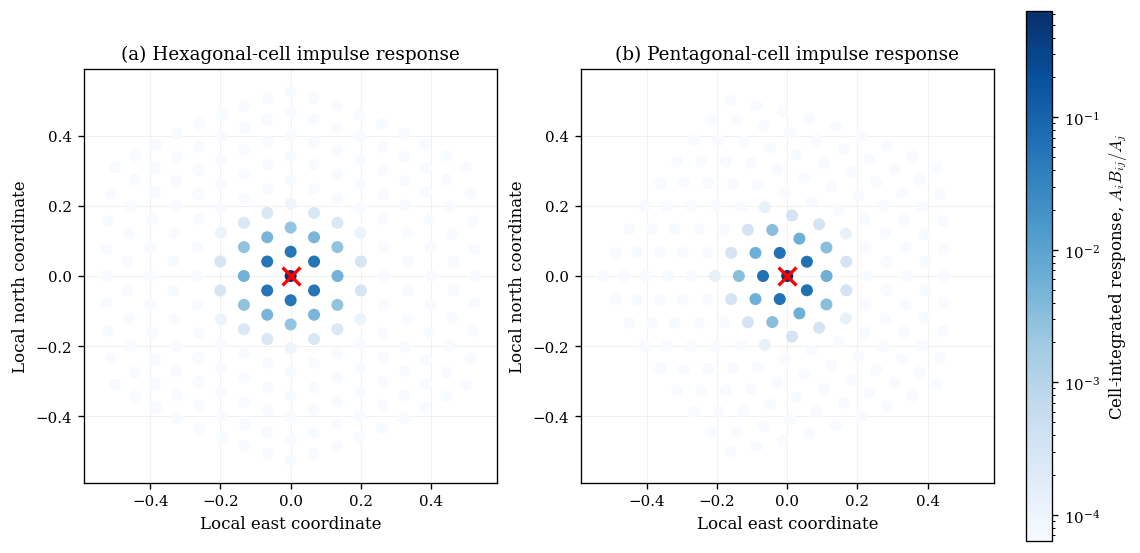

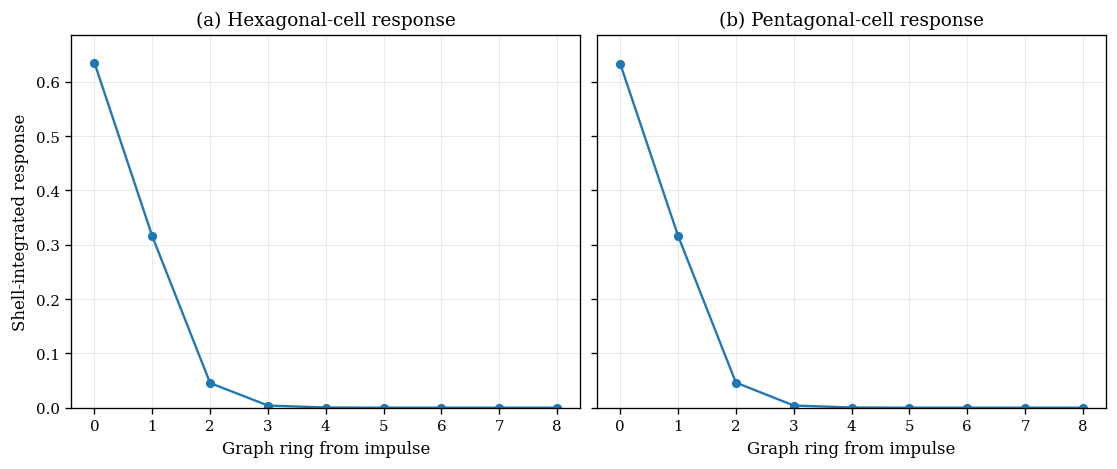

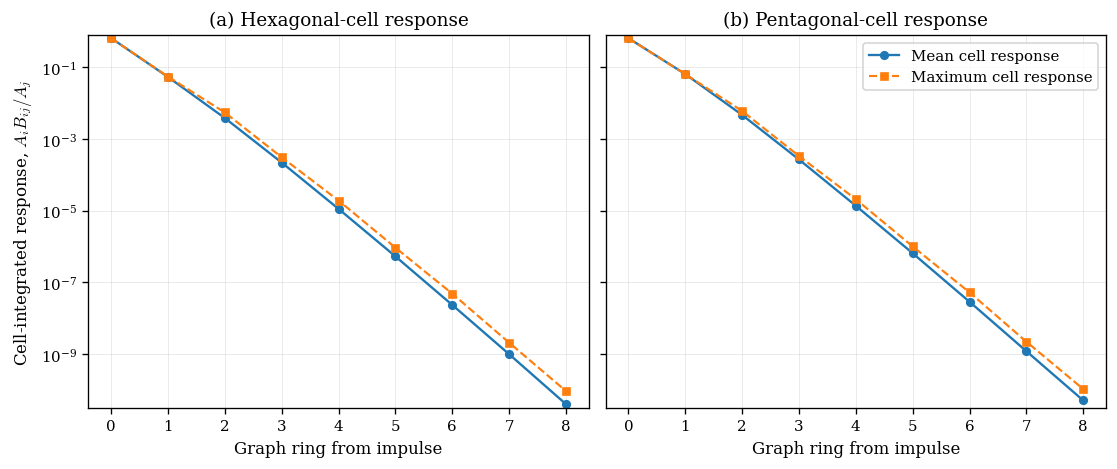

In [ ]:

# ============================================================
# Figures 9–11: Single-level area-compatible Graph Filter
#
# Final S1 formulation:
#
#     B_GF^(p) = [I + (mu/p) L_A]^(-p)
#
#     L_A = Ahat^(-1) Q
#     Q   = diag(W 1) - W
#
# W is a symmetric, area-balanced edge-weight matrix.
#
# Parameters:
#     p  = 5
#     mu = 0.50
#
# Figure 9:
#   Localized impulse responses for a hexagon and pentagon
#
# Figure 10:
#   Shell-integrated responses by graph ring
#
# Figure 11:
#   Mean and maximum local response decay by graph ring
#
# Additional diagnostics:
#   - Sinkhorn balancing
#   - Area-weighted self-adjointness
#   - Constant preservation
#   - Area-integral conservation
#   - Hexagon/pentagon central-response ratio
#   - Response mass within and outside the plotting window
#
# ============================================================

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm


# ============================================================
# Configuration
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = f"{PROJECT_ROOT}/grid"
PAPER_FIG_DIR = f"{PROJECT_ROOT}/paper_figures"

os.makedirs(PAPER_FIG_DIR, exist_ok=True)

# Retain the grid file used in the original experiment.
GRID_FILE = f"{GRID_DIR}/global_hex_ico_grid_v0.npz"

FIG09_PNG = (
    f"{PAPER_FIG_DIR}/fig09_local_impulse_response_S1_p5.png"
)
FIG09_PDF = (
    f"{PAPER_FIG_DIR}/fig09_local_impulse_response_S1_p5.pdf"
)

FIG10_PNG = (
    f"{PAPER_FIG_DIR}/fig10_shell_integrated_response_S1_p5.png"
)
FIG10_PDF = (
    f"{PAPER_FIG_DIR}/fig10_shell_integrated_response_S1_p5.pdf"
)

FIG11_PNG = (
    f"{PAPER_FIG_DIR}/fig11_local_response_decay_S1_p5.png"
)
FIG11_PDF = (
    f"{PAPER_FIG_DIR}/fig11_local_response_decay_S1_p5.pdf"
)

OUT_DATA = (
    f"{PAPER_FIG_DIR}/fig09_11_single_level_S1_p5_data.npz"
)


# ============================================================
# Filter parameters
# ============================================================

P_ORDER = 5
MU = 0.50

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000

MAX_PLOT_RING = 8

POINT_SIZE = 52
IMPULSE_MARKER_SIZE = 115

RESPONSE_CMAP = "Blues"

PNG_DPI = 600


# ============================================================
# Publication style
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "figure.dpi": 120,
    "savefig.dpi": PNG_DPI,
})


# ============================================================
# Load grid
# ============================================================

if not os.path.exists(GRID_FILE):
    raise FileNotFoundError(
        f"Grid file not found:\n{GRID_FILE}"
    )

grid = np.load(GRID_FILE, allow_pickle=True)

area = grid["cell_area"].astype(np.float64)

xyz = grid["cell_center_xyz"].astype(np.float64)
xyz /= np.linalg.norm(xyz, axis=1)[:, None]

lon_raw = grid["cell_center_lon"].astype(np.float64)
lat_raw = grid["cell_center_lat"].astype(np.float64)

if np.max(np.abs(lon_raw)) <= 2.0 * np.pi + 1.0e-6:
    lon = np.rad2deg(lon_raw)
    lat = np.rad2deg(lat_raw)
else:
    lon = lon_raw
    lat = lat_raw

ncells = area.size

if np.any(area <= 0.0):
    raise RuntimeError(
        "All finite-volume cell areas must be positive."
    )

print("=" * 72)
print("GRID")
print("=" * 72)

print("Grid file:", GRID_FILE)
print("Number of cells:", ncells)
print("Area min/max:", area.min(), area.max())
print("Total area:", area.sum())
print("Longitude range:", lon.min(), lon.max())
print("Latitude range:", lat.min(), lat.max())


# ============================================================
# Construct graph neighbors
# ============================================================

def build_neighbors_from_primal_faces(
    grid_data,
    number_of_cells
):
    """Construct cell neighbors from primal triangular faces."""

    faces = grid_data["primal_faces"]

    neighbors_local = [
        set() for _ in range(number_of_cells)
    ]

    for tri in faces:

        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[tri >= 0]

        if len(tri) != 3:
            continue

        a, b, c = tri

        neighbors_local[a].update((b, c))
        neighbors_local[b].update((a, c))
        neighbors_local[c].update((a, b))

    return [
        sorted(s) for s in neighbors_local
    ]


neighbors = build_neighbors_from_primal_faces(
    grid,
    ncells
)

degree = np.array(
    [len(nbrs) for nbrs in neighbors],
    dtype=np.int64
)

print("\nDegree counts:")

print({
    int(d): int(np.sum(degree == d))
    for d in sorted(set(degree))
})


# ============================================================
# Graph-ring utilities
# ============================================================

def graph_distance_from_cell(
    i0,
    neighbors_local,
    max_r=None
):
    """
    Breadth-first graph distance from source cell i0.

    If max_r is None, distances are calculated over the
    entire connected graph.
    """

    distance = -np.ones(
        len(neighbors_local),
        dtype=np.int64
    )

    distance[i0] = 0

    frontier = [i0]

    while frontier:

        new_frontier = []

        for q in frontier:

            if max_r is not None and distance[q] >= max_r:
                continue

            for j in neighbors_local[q]:

                if distance[j] < 0:

                    distance[j] = distance[q] + 1
                    new_frontier.append(j)

        frontier = new_frontier

    return distance


# ============================================================
# Construct symmetric graph adjacency
# ============================================================

def build_symmetric_adjacency(neighbors_local):

    n = len(neighbors_local)

    rows = []
    cols = []

    for i, nbrs in enumerate(neighbors_local):

        for j in nbrs:

            rows.append(i)
            cols.append(j)

    adjacency = sp.coo_matrix(
        (
            np.ones(len(rows), dtype=np.float64),
            (rows, cols)
        ),
        shape=(n, n)
    ).tocsr()

    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()

    adjacency = (
        0.5 * (adjacency + adjacency.T)
    ).tocsr()

    adjacency.eliminate_zeros()

    return adjacency


# ============================================================
# Final S1 area-compatible graph Laplacian
# ============================================================

def build_area_compatible_laplacian(
    neighbors_local,
    cell_area,
    sinkhorn_tol=SINKHORN_TOL,
    sinkhorn_maxiter=SINKHORN_MAXITER
):
    """
    Construct

        L_A = Ahat^(-1) Q

        Q = diag(W 1) - W

        W = diag(s) Adj diag(s)

    with symmetric area balancing:

        W 1 = ahat

    where

        ahat_i = A_i / mean(A).

    No degree-dependent correction is introduced.
    """

    adjacency = build_symmetric_adjacency(
        neighbors_local
    )

    n = adjacency.shape[0]

    ahat = (
        np.asarray(cell_area, dtype=np.float64)
        / np.mean(cell_area)
    )

    # --------------------------------------------------------
    # Symmetric Sinkhorn balancing
    # --------------------------------------------------------

    s = np.ones(n, dtype=np.float64)

    converged = False
    balance_error = np.inf

    for iteration in range(sinkhorn_maxiter):

        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(
                "Invalid adjacency during balancing."
            )

        s_new = np.sqrt(
            s * ahat / adjacency_s
        )

        row_sum_new = (
            s_new * (adjacency @ s_new)
        )

        balance_error = np.max(
            np.abs(row_sum_new - ahat)
            / ahat
        )

        s = s_new

        if balance_error < sinkhorn_tol:

            converged = True
            break

    if not converged:
        raise RuntimeError(
            "Symmetric balancing failed to converge. "
            f"Final error = {balance_error:.3e}"
        )

    # --------------------------------------------------------
    # Symmetric balanced edge-weight matrix
    # --------------------------------------------------------

    Wedge = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    Wedge = (
        0.5 * (Wedge + Wedge.T)
    ).tocsr()

    Wedge.eliminate_zeros()

    row_sum = np.asarray(
        Wedge @ np.ones(n)
    ).ravel()

    # --------------------------------------------------------
    # Symmetric graph stiffness matrix
    # --------------------------------------------------------

    Q = (
        sp.diags(row_sum)
        - Wedge
    ).tocsr()

    # --------------------------------------------------------
    # Area-compatible graph Laplacian
    # --------------------------------------------------------

    L_A = (
        sp.diags(1.0 / ahat)
        @ Q
    ).tocsr()

    # --------------------------------------------------------
    # Operator diagnostics
    # --------------------------------------------------------

    Ahat = sp.diags(ahat)

    constant_null_error = np.max(
        np.abs(L_A @ np.ones(n))
    )

    weighted_adjoint_error = (
        spla.norm(
            Ahat @ L_A
            - L_A.T @ Ahat
        )
        /
        max(
            spla.norm(Ahat @ L_A),
            1.0e-300
        )
    )

    W_symmetry_error = (
        spla.norm(Wedge - Wedge.T)
        /
        max(
            spla.norm(Wedge),
            1.0e-300
        )
    )

    Q_symmetry_error = (
        spla.norm(Q - Q.T)
        /
        max(
            spla.norm(Q),
            1.0e-300
        )
    )

    final_balance_error = np.max(
        np.abs(row_sum - ahat) / ahat
    )

    print("\n" + "=" * 72)
    print("S1 AREA-COMPATIBLE GRAPH OPERATOR")
    print("=" * 72)

    print("Number of cells              :", n)
    print("Sinkhorn iterations          :", iteration + 1)

    print(
        "Balance relative error       :",
        final_balance_error
    )

    print(
        "W symmetry relative error    :",
        W_symmetry_error
    )

    print(
        "Q symmetry relative error    :",
        Q_symmetry_error
    )

    print(
        "Constant-null error          :",
        constant_null_error
    )

    print(
        "Weighted-adjoint relative err:",
        weighted_adjoint_error
    )

    return (
        L_A,
        Wedge,
        Q,
        ahat,
        final_balance_error,
        constant_null_error,
        weighted_adjoint_error
    )


(
    L_A,
    Wedge,
    Q,
    ahat,
    balance_error,
    constant_null_error,
    operator_adjoint_error
) = build_area_compatible_laplacian(
    neighbors,
    area
)


# ============================================================
# Repeated-resolvent Graph Filter
# ============================================================

system = (
    sp.eye(ncells, format="csr")
    + (MU / float(P_ORDER)) * L_A
)

solve = spla.factorized(
    system.tocsc()
)


def B_apply(field):
    """
    Apply

        B_GF^(p) = [I + (mu/p)L_A]^(-p).
    """

    y = np.asarray(
        field,
        dtype=np.float64
    ).copy()

    for _ in range(P_ORDER):
        y = solve(y)

    return y


def inner_A(x, y):
    return np.dot(
        x,
        area * y
    )


def integral_A(x):
    return np.dot(
        area,
        x
    )


def mean_A(x):
    return integral_A(x) / np.sum(area)


# ============================================================
# Filter-level mathematical diagnostics
# ============================================================

rng = np.random.default_rng(1234)

x_test = rng.standard_normal(ncells)
y_test = rng.standard_normal(ncells)

Bx = B_apply(x_test)
By = B_apply(y_test)

lhs = inner_A(x_test, By)
rhs = inner_A(Bx, y_test)

self_adjoint_error = (
    abs(lhs - rhs)
    /
    max(
        abs(lhs),
        abs(rhs),
        1.0e-300
    )
)

constant_field = np.ones(ncells)

B_constant = B_apply(constant_field)

constant_preservation_error = np.max(
    np.abs(B_constant - constant_field)
)

# A deliberately nonzero-mean field gives a well-conditioned
# relative conservation diagnostic.

conservation_field = x_test + 1.0

B_conservation_field = B_apply(
    conservation_field
)

integral_before = integral_A(
    conservation_field
)

integral_after = integral_A(
    B_conservation_field
)

conservation_relative_error = (
    abs(integral_after - integral_before)
    /
    max(
        abs(integral_before),
        1.0e-300
    )
)

positive_quadratic_form = inner_A(
    x_test,
    Bx
)

print("\n" + "=" * 72)
print("SINGLE-LEVEL GRAPH FILTER DIAGNOSTICS")
print("=" * 72)

print("Repeated-resolvent order p =", P_ORDER)
print("Filter parameter mu        =", MU)

print(
    "Area-weighted self-adjointness error =",
    self_adjoint_error
)

print(
    "Constant-preservation error         =",
    constant_preservation_error
)

print(
    "Integral before filtering           =",
    integral_before
)

print(
    "Integral after filtering            =",
    integral_after
)

print(
    "Relative conservation error         =",
    conservation_relative_error
)

print(
    "Area-weighted quadratic form        =",
    positive_quadratic_form
)


# ============================================================
# Select impulse cells
# ============================================================

# Retain the original equatorial source selection.
#
# Explicitly require degree 6 so that the selected cell is
# a regular hexagon.

hexagon_indices = np.where(degree == 6)[0]

if len(hexagon_indices) == 0:
    raise RuntimeError(
        "No hexagonal cells were found."
    )

hex_distance = (
    lon[hexagon_indices] ** 2
    + lat[hexagon_indices] ** 2
)

i_equator = int(
    hexagon_indices[np.argmin(hex_distance)]
)

# Retain the first pentagonal cell.

pentagon_indices = np.where(degree == 5)[0]

if len(pentagon_indices) == 0:
    raise RuntimeError(
        "No pentagonal cells were found."
    )

i_pentagon = int(pentagon_indices[0])


print("\n" + "=" * 72)
print("IMPULSE SOURCE CELLS")
print("=" * 72)

for label, i0 in [
    ("Hexagon", i_equator),
    ("Pentagon", i_pentagon)
]:

    print(
        f"{label}: cell={i0}, "
        f"lon={lon[i0]:.6f}, "
        f"lat={lat[i0]:.6f}, "
        f"degree={degree[i0]}, "
        f"area={area[i0]:.8e}"
    )


# ============================================================
# Compute complete impulse responses
# ============================================================

def compute_impulse_response(i0):
    """
    Apply the Graph Filter to a unit-area impulse.

    The source impulse is

        delta_j = 1 / A_j.

    Its area-weighted integral is unity.

    Graph distances are calculated over the complete graph.
    """

    delta = np.zeros(
        ncells,
        dtype=np.float64
    )

    delta[i0] = 1.0 / area[i0]

    response = B_apply(delta)

    distance = graph_distance_from_cell(
        i0,
        neighbors,
        max_r=None
    )

    if np.any(distance < 0):
        raise RuntimeError(
            "The graph contains cells unreachable "
            "from the impulse source."
        )

    return delta, response, distance


(
    delta_hex,
    response_hex,
    distance_hex
) = compute_impulse_response(i_equator)

(
    delta_pent,
    response_pent,
    distance_pent
) = compute_impulse_response(i_pentagon)


# ============================================================
# Complete impulse diagnostics
# ============================================================

def impulse_diagnostics(
    i0,
    delta,
    response,
    distance,
    label
):

    # Cell-integrated response.
    response_mass = area * response

    total_mass = np.sum(response_mass)

    source_mass = response_mass[i0]

    inside_mask = (
        distance <= MAX_PLOT_RING
    )

    mass_inside = np.sum(
        response_mass[inside_mask]
    )

    mass_outside = np.sum(
        response_mass[~inside_mask]
    )

    # Relative impulse-integral error.
    source_integral = integral_A(delta)

    relative_integral_error = (
        abs(total_mass - source_integral)
        /
        max(
            abs(source_integral),
            1.0e-300
        )
    )

    # Small negative values may arise from numerical roundoff.
    minimum_response_mass = np.min(
        response_mass
    )

    maximum_response_mass = np.max(
        response_mass
    )

    # Full graph-ring distribution.
    maximum_ring = int(
        np.max(distance)
    )

    shell_mass_full = np.bincount(
        distance,
        weights=response_mass,
        minlength=maximum_ring + 1
    )

    print("\n" + "=" * 72)
    print(label)
    print("=" * 72)

    print("Source cell                 :", i0)
    print("Degree                      :", degree[i0])
    print("Area                        :", area[i0])

    print("\nArea-integral conservation:")

    print(
        "Impulse integral            :",
        source_integral
    )

    print(
        "Filtered impulse integral   :",
        total_mass
    )

    print(
        "Relative integral error     :",
        relative_integral_error
    )

    print("\nCentral and extrema diagnostics:")

    print(
        "Central cell-integrated response:",
        source_mass
    )

    print(
        "Maximum cell-integrated response:",
        maximum_response_mass
    )

    print(
        "Minimum cell-integrated response:",
        minimum_response_mass
    )

    print("\nLocalization diagnostics:")

    print(
        "Maximum graph distance      :",
        maximum_ring
    )

    print(
        "Mass within plotted rings   :",
        mass_inside
    )

    print(
        "Mass outside plotted rings  :",
        mass_outside
    )

    print(
        "Fraction within plotted rings:",
        mass_inside / total_mass
    )

    print(
        "Fraction outside plotted rings:",
        mass_outside / total_mass
    )

    print("\nShell-integrated response:")

    for ring in range(MAX_PLOT_RING + 1):

        shell_value = shell_mass_full[ring]

        print(
            f"  ring {ring:2d}: "
            f"{shell_value:.10e}"
        )

    return {
        "central_mass": source_mass,
        "total_mass": total_mass,
        "mass_inside": mass_inside,
        "mass_outside": mass_outside,
        "fraction_inside": mass_inside / total_mass,
        "fraction_outside": mass_outside / total_mass,
        "relative_integral_error": relative_integral_error,
        "maximum_ring": maximum_ring,
        "shell_mass_full": shell_mass_full,
        "minimum_mass": minimum_response_mass,
        "maximum_mass": maximum_response_mass,
    }


diag_hex = impulse_diagnostics(
    i_equator,
    delta_hex,
    response_hex,
    distance_hex,
    "HEXAGONAL-CELL IMPULSE"
)

diag_pent = impulse_diagnostics(
    i_pentagon,
    delta_pent,
    response_pent,
    distance_pent,
    "PENTAGONAL-CELL IMPULSE"
)


# ============================================================
# Hexagon–pentagon central-response comparison
# ============================================================

central_hex = diag_hex["central_mass"]
central_pent = diag_pent["central_mass"]

central_ratio = (
    central_pent / central_hex
)

central_relative_difference = (
    abs(central_pent - central_hex)
    /
    abs(central_hex)
)

print("\n" + "=" * 72)
print("HEXAGON–PENTAGON CENTRAL-RESPONSE COMPARISON")
print("=" * 72)

print(
    "Hexagonal central response  :",
    central_hex
)

print(
    "Pentagonal central response :",
    central_pent
)

print(
    "Pentagon/hexagon ratio      :",
    central_ratio
)

print(
    "Relative central difference :",
    central_relative_difference
)


# ============================================================
# Local tangent-plane coordinates
# ============================================================

def tangent_coordinates(i0, mask):
    """
    Project selected cell centers onto a local tangent plane.

    Coordinates are dimensionless, normalized by sphere radius.
    """

    center = xyz[i0].astype(np.float64)
    center /= np.linalg.norm(center)

    z_axis = np.array([
        0.0, 0.0, 1.0
    ])

    east = np.cross(
        z_axis,
        center
    )

    if np.linalg.norm(east) < 1.0e-12:

        east = np.array([
            1.0, 0.0, 0.0
        ])

    else:

        east /= np.linalg.norm(east)

    north = np.cross(
        center,
        east
    )

    north /= np.linalg.norm(north)

    selected_xyz = xyz[mask].astype(
        np.float64
    )

    selected_xyz /= np.linalg.norm(
        selected_xyz,
        axis=1
    )[:, None]

    displacement = (
        selected_xyz
        - center[None, :]
    )

    local_east = displacement @ east
    local_north = displacement @ north

    return local_east, local_north


def local_response_data(
    i0,
    response,
    distance,
    max_ring=MAX_PLOT_RING
):

    mask = (
        (distance >= 0)
        & (distance <= max_ring)
    )

    local_east, local_north = tangent_coordinates(
        i0,
        mask
    )

    response_mass = (
        area[mask] * response[mask]
    )

    return (
        local_east,
        local_north,
        response_mass,
        mask
    )


(
    xe_hex,
    yn_hex,
    mass_hex,
    mask_hex
) = local_response_data(
    i_equator,
    response_hex,
    distance_hex
)

(
    xe_pent,
    yn_pent,
    mass_pent,
    mask_pent
) = local_response_data(
    i_pentagon,
    response_pent,
    distance_pent
)


# ============================================================
# Shared logarithmic normalization for Figure 9
# ============================================================

all_positive_values = np.concatenate([
    mass_hex[mass_hex > 0.0],
    mass_pent[mass_pent > 0.0]
])

if all_positive_values.size == 0:

    raise RuntimeError(
        "The impulse responses contain no positive values."
    )

response_vmax = np.max(
    all_positive_values
)

# As in the original script, avoid allowing extremely
# small tails to dominate the plotted color scale.

response_vmin = max(
    np.min(all_positive_values),
    response_vmax * 1.0e-4
)

response_norm = LogNorm(
    vmin=response_vmin,
    vmax=response_vmax
)


# ============================================================
# Figure 9: localized impulse responses
# ============================================================

fig9, axes9 = plt.subplots(
    1,
    2,
    figsize=(9.4, 4.5),
    constrained_layout=True
)

panel_data = [
    (
        axes9[0],
        xe_hex,
        yn_hex,
        mass_hex,
        r"(a) Hexagonal-cell impulse response"
    ),
    (
        axes9[1],
        xe_pent,
        yn_pent,
        mass_pent,
        r"(b) Pentagonal-cell impulse response"
    ),
]

scatter9 = None

for ax, xe, yn, response_mass, title in panel_data:

    scatter9 = ax.scatter(
        xe,
        yn,
        c=response_mass,
        s=POINT_SIZE,
        cmap=RESPONSE_CMAP,
        norm=response_norm,
        edgecolors="none",
        rasterized=True,
        zorder=2
    )

    ax.scatter(
        [0.0],
        [0.0],
        marker="x",
        s=IMPULSE_MARKER_SIZE,
        c="red",
        linewidths=2.0,
        zorder=4
    )

    ax.set_title(
        title,
        pad=6
    )

    ax.set_xlabel(
        "Local east coordinate"
    )

    ax.set_ylabel(
        "Local north coordinate"
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(
        True,
        linewidth=0.4,
        alpha=0.25
    )


# Identical limits for direct comparison.

x_extent = max(
    np.max(np.abs(xe_hex)),
    np.max(np.abs(xe_pent))
)

y_extent = max(
    np.max(np.abs(yn_hex)),
    np.max(np.abs(yn_pent))
)

padding = 1.12

for ax in axes9:

    ax.set_xlim(
        -padding * x_extent,
        padding * x_extent
    )

    ax.set_ylim(
        -padding * y_extent,
        padding * y_extent
    )


colorbar9 = fig9.colorbar(
    scatter9,
    ax=axes9,
    orientation="vertical",
    fraction=0.040,
    pad=0.035
)

colorbar9.set_label(
    r"Cell-integrated response, $A_i B_{ij}/A_j$"
)


fig9.savefig(
    FIG09_PNG,
    dpi=PNG_DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig9.savefig(
    FIG09_PDF,
    bbox_inches="tight",
    facecolor="white"
)


# ============================================================
# Graph-ring response diagnostics
# ============================================================

def radial_response_data(
    response,
    distance,
    max_ring=MAX_PLOT_RING
):

    rings = []
    shell_mass = []
    mean_cell_mass = []
    maximum_cell_mass = []

    for ring in range(max_ring + 1):

        mask = (
            distance == ring
        )

        if not np.any(mask):
            continue

        cell_mass = (
            area[mask] * response[mask]
        )

        rings.append(ring)

        shell_mass.append(
            np.sum(cell_mass)
        )

        mean_cell_mass.append(
            np.mean(cell_mass)
        )

        maximum_cell_mass.append(
            np.max(cell_mass)
        )

    return (
        np.asarray(rings),
        np.asarray(shell_mass),
        np.asarray(mean_cell_mass),
        np.asarray(maximum_cell_mass)
    )


(
    rings_hex,
    shell_hex,
    mean_hex,
    maximum_hex
) = radial_response_data(
    response_hex,
    distance_hex
)

(
    rings_pent,
    shell_pent,
    mean_pent,
    maximum_pent
) = radial_response_data(
    response_pent,
    distance_pent
)


# ============================================================
# Figure 10: shell-integrated responses
# ============================================================

fig10, axes10 = plt.subplots(
    1,
    2,
    figsize=(9.2, 3.8),
    constrained_layout=True,
    sharex=True,
    sharey=True
)


axes10[0].plot(
    rings_hex,
    shell_hex,
    marker="o",
    linewidth=1.4,
    markersize=4.5
)

axes10[1].plot(
    rings_pent,
    shell_pent,
    marker="o",
    linewidth=1.4,
    markersize=4.5
)


axes10[0].set_title(
    r"(a) Hexagonal-cell response"
)

axes10[1].set_title(
    r"(b) Pentagonal-cell response"
)


for ax in axes10:

    ax.set_xlabel(
        "Graph ring from impulse"
    )

    ax.grid(
        True,
        linewidth=0.45,
        alpha=0.35
    )

    ax.set_xticks(
        np.arange(
            0,
            MAX_PLOT_RING + 1,
            1
        )
    )


axes10[0].set_ylabel(
    "Shell-integrated response"
)


shell_ymax = 1.08 * max(
    np.max(shell_hex),
    np.max(shell_pent)
)

axes10[0].set_ylim(
    0.0,
    shell_ymax
)


fig10.savefig(
    FIG10_PNG,
    dpi=PNG_DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig10.savefig(
    FIG10_PDF,
    bbox_inches="tight",
    facecolor="white"
)



# ============================================================
# Figure 11: local response decay
# Logarithmic vertical scale
# ============================================================

fig11, axes11 = plt.subplots(
    1,
    2,
    figsize=(9.2, 3.8),
    constrained_layout=True,
    sharex=True,
    sharey=True
)


axes11[0].plot(
    rings_hex,
    mean_hex,
    marker="o",
    linewidth=1.4,
    markersize=4.5,
    label="Mean cell response"
)

axes11[0].plot(
    rings_hex,
    maximum_hex,
    marker="s",
    linestyle="--",
    linewidth=1.3,
    markersize=4.2,
    label="Maximum cell response"
)


axes11[1].plot(
    rings_pent,
    mean_pent,
    marker="o",
    linewidth=1.4,
    markersize=4.5,
    label="Mean cell response"
)

axes11[1].plot(
    rings_pent,
    maximum_pent,
    marker="s",
    linestyle="--",
    linewidth=1.3,
    markersize=4.2,
    label="Maximum cell response"
)


axes11[0].set_title(
    r"(a) Hexagonal-cell response"
)

axes11[1].set_title(
    r"(b) Pentagonal-cell response"
)


for ax in axes11:

    ax.set_xlabel(
        "Graph ring from impulse"
    )

    ax.set_yscale("log")

    ax.grid(
        True,
        which="both",
        linewidth=0.45,
        alpha=0.35
    )

    ax.set_xticks(
        np.arange(
            0,
            MAX_PLOT_RING + 1,
            1
        )
    )


axes11[0].set_ylabel(
    r"Cell-integrated response, $A_i B_{ij}/A_j$"
)


# ============================================================
# Common logarithmic vertical limits
# ============================================================

all_decay_values = np.concatenate([
    mean_hex,
    maximum_hex,
    mean_pent,
    maximum_pent
])

positive_decay_values = all_decay_values[
    all_decay_values > 0.0
]

if positive_decay_values.size == 0:
    raise RuntimeError(
        "Figure 11 contains no positive response values."
    )

decay_ymin = 0.8 * np.min(
    positive_decay_values
)

decay_ymax = 1.2 * np.max(
    positive_decay_values
)

axes11[0].set_ylim(
    decay_ymin,
    decay_ymax
)


axes11[1].legend(
    loc="upper right",
    frameon=True
)


fig11.savefig(
    FIG11_PNG,
    dpi=PNG_DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig11.savefig(
    FIG11_PDF,
    bbox_inches="tight",
    facecolor="white"
)

# ============================================================
# Save numerical data
# ============================================================

np.savez(
    OUT_DATA,

    # Grid and impulse sources
    i_equator=i_equator,
    i_pentagon=i_pentagon,
    lon=lon,
    lat=lat,
    area=area,
    degree=degree,

    # Impulse fields and complete responses
    delta_hex=delta_hex,
    delta_pent=delta_pent,
    response_hex=response_hex,
    response_pent=response_pent,

    # Complete graph distances
    distance_hex=distance_hex,
    distance_pent=distance_pent,

    # Local coordinates and response masses
    xe_hex=xe_hex,
    yn_hex=yn_hex,
    mass_hex=mass_hex,

    xe_pent=xe_pent,
    yn_pent=yn_pent,
    mass_pent=mass_pent,

    # Graph-ring diagnostics
    rings_hex=rings_hex,
    shell_hex=shell_hex,
    mean_hex=mean_hex,
    maximum_hex=maximum_hex,

    rings_pent=rings_pent,
    shell_pent=shell_pent,
    mean_pent=mean_pent,
    maximum_pent=maximum_pent,

    # Complete shell distributions
    shell_mass_full_hex=diag_hex["shell_mass_full"],
    shell_mass_full_pent=diag_pent["shell_mass_full"],

    # Central responses
    central_hex=central_hex,
    central_pent=central_pent,
    central_ratio=central_ratio,
    central_relative_difference=central_relative_difference,

    # Localization
    mass_inside_hex=diag_hex["mass_inside"],
    mass_outside_hex=diag_hex["mass_outside"],
    mass_inside_pent=diag_pent["mass_inside"],
    mass_outside_pent=diag_pent["mass_outside"],

    fraction_inside_hex=diag_hex["fraction_inside"],
    fraction_outside_hex=diag_hex["fraction_outside"],
    fraction_inside_pent=diag_pent["fraction_inside"],
    fraction_outside_pent=diag_pent["fraction_outside"],

    # Mathematical diagnostics
    balance_error=balance_error,
    constant_null_error=constant_null_error,
    operator_adjoint_error=operator_adjoint_error,

    self_adjoint_error=self_adjoint_error,
    constant_preservation_error=constant_preservation_error,
    conservation_relative_error=conservation_relative_error,

    impulse_integral_error_hex=diag_hex[
        "relative_integral_error"
    ],
    impulse_integral_error_pent=diag_pent[
        "relative_integral_error"
    ],

    positive_quadratic_form=positive_quadratic_form,

    # Filter parameters
    p_order=P_ORDER,
    mu=MU,
    max_plot_ring=MAX_PLOT_RING
)


# ============================================================
# Report saved files
# ============================================================

print("\n" + "=" * 72)
print("PUBLICATION OUTPUT")
print("=" * 72)

print("Saved Figure 9 PNG :", FIG09_PNG)
print("Saved Figure 9 PDF :", FIG09_PDF)

print("Saved Figure 10 PNG:", FIG10_PNG)
print("Saved Figure 10 PDF:", FIG10_PDF)

print("Saved Figure 11 PNG:", FIG11_PNG)
print("Saved Figure 11 PDF:", FIG11_PDF)

print("Saved numerical data:", OUT_DATA)

plt.show()

# New Table 3

In [ ]:

# ============================================================
# TABLE 3: Global impulse-response diagnostics
#
# Final S1 area-compatible Graph Filter
# Same grid and operator as Figures 9-11
#
# Run AFTER the completed Figures 9-11 cell.
#
# Diagnostics for every source cell:
#   1. Effective covariance radius
#   2. Tangent-plane anisotropy
#   3. Centroid displacement
#   4. Relative area-integral error
#   5. Central cell-integrated response
#   6. Fraction of integrated response outside ring 8
#
# Additional:
#   - Smallest graph radius satisfying tail < 1e-8
#   - Degree-group summaries
#   - Save complete numerical results
# ============================================================

import os
from collections import deque

import numpy as np


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

EARTH_RADIUS_KM = 6371.0

TAIL_TOL = 1.0e-8
TABLE_RING = 8

TABLE3_FILE = os.path.join(
    PAPER_FIG_DIR,
    "table03_global_impulse_diagnostics_S1_p5.npz"
)

TABLE3_TEXT = os.path.join(
    PAPER_FIG_DIR,
    "table03_global_impulse_diagnostics_S1_p5.txt"
)


# ------------------------------------------------------------
# Verify that the previous cell has been executed
# ------------------------------------------------------------

required_variables = [
    "area",
    "xyz",
    "neighbors",
    "ncells",
    "degree",
    "B_apply",
    "P_ORDER",
    "MU",
    "PAPER_FIG_DIR",
]

missing = [
    name for name in required_variables
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Run the complete Figures 9-11 cell first. "
        f"Missing variables: {missing}"
    )

if ncells != 2562:
    raise RuntimeError(
        f"Expected 2562 cells, found {ncells}."
    )

if P_ORDER != 5 or not np.isclose(MU, 0.5):
    raise RuntimeError(
        "Unexpected filter parameters. "
        f"Found p={P_ORDER}, mu={MU}."
    )

area = np.asarray(area, dtype=np.float64)
xyz = np.asarray(xyz, dtype=np.float64)

xyz = xyz / np.linalg.norm(
    xyz, axis=1
)[:, None]

if area.shape != (ncells,):
    raise RuntimeError("Unexpected cell-area shape.")

if xyz.shape != (ncells, 3):
    raise RuntimeError("Unexpected cell-center shape.")

if np.any(area <= 0.0):
    raise RuntimeError("Cell areas must be positive.")

os.makedirs(PAPER_FIG_DIR, exist_ok=True)


# ------------------------------------------------------------
# Tangent-plane geometry
#
# The displacement coordinates are expressed in kilometers.
# They use the spherical logarithmic map at the source cell.
# ------------------------------------------------------------

def tangent_basis(source_xyz):

    reference = np.array(
        [0.0, 0.0, 1.0],
        dtype=np.float64
    )

    east = np.cross(reference, source_xyz)

    if np.linalg.norm(east) < 1.0e-12:

        reference = np.array(
            [1.0, 0.0, 0.0],
            dtype=np.float64
        )

        east = np.cross(reference, source_xyz)

    east /= np.linalg.norm(east)

    north = np.cross(source_xyz, east)
    north /= np.linalg.norm(north)

    return east, north


def source_geometry(source):

    center = xyz[source]

    dot = np.clip(
        xyz @ center,
        -1.0,
        1.0
    )

    angular_distance = np.arccos(dot)

    distance_km = (
        EARTH_RADIUS_KM * angular_distance
    )

    east, north = tangent_basis(center)

    tangent_vector = (
        xyz - dot[:, None] * center[None, :]
    )

    tangent_norm = np.linalg.norm(
        tangent_vector,
        axis=1
    )

    factor = np.zeros(ncells, dtype=np.float64)

    good = tangent_norm > 1.0e-14

    factor[good] = (
        distance_km[good] / tangent_norm[good]
    )

    tangent_vector *= factor[:, None]

    tx = tangent_vector @ east
    ty = tangent_vector @ north

    # Set the source displacement exactly to zero.
    distance_km[source] = 0.0
    tx[source] = 0.0
    ty[source] = 0.0

    return distance_km, tx, ty


# ------------------------------------------------------------
# Full-graph shortest-path distances
# ------------------------------------------------------------

def all_graph_distances(source):

    distance = np.full(
        ncells,
        -1,
        dtype=np.int32
    )

    distance[source] = 0

    queue = deque([int(source)])

    while queue:

        i = queue.popleft()

        for j in neighbors[i]:

            if distance[j] < 0:

                distance[j] = distance[i] + 1

                queue.append(int(j))

    if np.any(distance < 0):
        raise RuntimeError(
            f"Disconnected graph for source {source}."
        )

    return distance


# ------------------------------------------------------------
# Allocate all-source diagnostic arrays
# ------------------------------------------------------------

effective_radius_km = np.zeros(ncells)
anisotropy = np.zeros(ncells)
centroid_shift_km = np.zeros(ncells)

relative_integral_error = np.zeros(ncells)
central_response = np.zeros(ncells)

tail_fraction_ring8 = np.zeros(ncells)
effective_graph_radius = np.zeros(
    ncells,
    dtype=np.int32
)

maximum_graph_distance = np.zeros(
    ncells,
    dtype=np.int32
)

# Retain all-source shell masses for further analysis.
shell_mass_by_source = np.zeros(
    (ncells, ncells),
    dtype=np.float64
)


# ------------------------------------------------------------
# Evaluate every unit-area impulse
# ------------------------------------------------------------

print("=" * 72)
print("TABLE 3: GLOBAL S1 IMPULSE DIAGNOSTICS")
print("=" * 72)

print("Number of source cells :", ncells)
print("Filter order p         :", P_ORDER)
print("Filter parameter mu    :", MU)
print("Tail tolerance         :", TAIL_TOL)
print("Table graph ring       :", TABLE_RING)

for source in range(ncells):

    # --------------------------------------------------------
    # Unit-area impulse
    # --------------------------------------------------------

    impulse = np.zeros(
        ncells,
        dtype=np.float64
    )

    impulse[source] = 1.0 / area[source]

    response = B_apply(impulse)

    # Cell-integrated response.
    mass = area * response

    impulse_integral = np.dot(area, impulse)
    response_integral = np.sum(mass)

    if not np.all(np.isfinite(mass)):
        raise RuntimeError(
            f"Nonfinite response for source {source}."
        )

    if response_integral <= 0.0:
        raise RuntimeError(
            f"Nonpositive integral for source {source}."
        )

    # The S1 resolvent is positivity preserving.
    # Allow only tiny negative values attributable to roundoff.

    if np.min(mass) < -1.0e-13:
        raise RuntimeError(
            f"Unexpected negative response for source {source}: "
            f"{np.min(mass):.6e}"
        )

    # --------------------------------------------------------
    # Area-integral error and central response
    # --------------------------------------------------------

    relative_integral_error[source] = (
        abs(response_integral - impulse_integral)
        / abs(impulse_integral)
    )

    central_response[source] = mass[source]

    # --------------------------------------------------------
    # Physical response geometry
    # --------------------------------------------------------

    distance_km, tx, ty = source_geometry(source)

    effective_radius_km[source] = np.sqrt(
        max(
            np.sum(mass * distance_km**2)
            / response_integral,
            0.0
        )
    )

    mx = np.sum(mass * tx) / response_integral
    my = np.sum(mass * ty) / response_integral

    centroid_shift_km[source] = np.hypot(
        mx,
        my
    )

    dx = tx - mx
    dy = ty - my

    Cxx = (
        np.sum(mass * dx * dx)
        / response_integral
    )

    Cyy = (
        np.sum(mass * dy * dy)
        / response_integral
    )

    Cxy = (
        np.sum(mass * dx * dy)
        / response_integral
    )

    covariance = np.array([
        [Cxx, Cxy],
        [Cxy, Cyy]
    ])

    eigenvalues = np.linalg.eigvalsh(covariance)

    if eigenvalues[0] <= 0.0:
        raise RuntimeError(
            f"Invalid covariance eigenvalue "
            f"for source {source}: {eigenvalues}"
        )

    anisotropy[source] = np.sqrt(
        eigenvalues[1] / eigenvalues[0]
    )

    # --------------------------------------------------------
    # Complete graph-ring distribution
    # --------------------------------------------------------

    graph_distance = all_graph_distances(source)

    max_ring = int(np.max(graph_distance))

    maximum_graph_distance[source] = max_ring

    shell_mass = np.bincount(
        graph_distance,
        weights=mass,
        minlength=max_ring + 1
    )

    shell_mass_by_source[
        source,
        :len(shell_mass)
    ] = shell_mass

    # --------------------------------------------------------
    # Fraction outside graph ring 8
    # --------------------------------------------------------

    tail_mass = np.sum(
        shell_mass[TABLE_RING + 1:]
    )

    tail_fraction_ring8[source] = (
        tail_mass / response_integral
    )

    # --------------------------------------------------------
    # Smallest graph radius satisfying tail < 1e-8
    #
    # Use the complete remaining tail, not the value of
    # the response at one individual ring.
    # --------------------------------------------------------

    remaining_mass = (
        response_integral
        - np.cumsum(shell_mass)
    )

    # Clip tiny negative values from floating-point summation.
    remaining_mass = np.maximum(
        remaining_mass,
        0.0
    )

    remaining_fraction = (
        remaining_mass / response_integral
    )

    acceptable_rings = np.where(
        remaining_fraction < TAIL_TOL
    )[0]

    if acceptable_rings.size == 0:
        raise RuntimeError(
            f"No effective radius found for source {source}."
        )

    effective_graph_radius[source] = int(
        acceptable_rings[0]
    )

    if (
        (source + 1) % 250 == 0
        or source == ncells - 1
    ):

        print(
            f"Completed {source + 1:4d}/{ncells} "
            f"source cells"
        )


# ------------------------------------------------------------
# Global statistics
# ------------------------------------------------------------

diagnostics = [
    (
        "Effective radius (km)",
        effective_radius_km
    ),
    (
        "Anisotropy",
        anisotropy
    ),
    (
        "Centroid shift (km)",
        centroid_shift_km
    ),
    (
        "Relative integral error (1e-15)",
        relative_integral_error / 1.0e-15
    ),
    (
        "Central integrated response",
        central_response
    ),
    (
        "Tail fraction outside ring 8",
        tail_fraction_ring8
    ),
]

report = []

report.append("=" * 100)
report.append(
    "TABLE 3: GLOBAL IMPULSE-RESPONSE STATISTICS"
)
report.append("=" * 100)

report.append(
    f"Grid cells: {ncells}; "
    f"p={P_ORDER}; mu={MU}; "
    f"tail tolerance={TAIL_TOL:.1e}"
)

report.append("")

report.append(
    f"{'Diagnostic':37s}"
    f"{'Minimum':>15s}"
    f"{'Mean':>15s}"
    f"{'Std. dev.':>15s}"
    f"{'Maximum':>15s}"
)

report.append("-" * 97)

for label, values in diagnostics:

    values = np.asarray(values, dtype=np.float64)

    report.append(
        f"{label:37s}"
        f"{np.min(values):15.7e}"
        f"{np.mean(values):15.7e}"
        f"{np.std(values):15.7e}"
        f"{np.max(values):15.7e}"
    )


# ------------------------------------------------------------
# Additional effective-radius statistics
# ------------------------------------------------------------

report.append("")
report.append(
    "EFFECTIVE GRAPH RADIUS: "
    "smallest R with tail fraction < 1e-8"
)

unique_radii, radius_counts = np.unique(
    effective_graph_radius,
    return_counts=True
)

for radius, count in zip(
    unique_radii,
    radius_counts
):

    report.append(
        f"R = {radius:2d}: "
        f"{count:4d} source cells"
    )

report.append("")

report.append(
    "Effective graph radius: "
    f"min={np.min(effective_graph_radius)}, "
    f"mean={np.mean(effective_graph_radius):.6f}, "
    f"max={np.max(effective_graph_radius)}"
)

report.append("")

report.append(
    "GLOBAL LOCALIZATION CHECK"
)

report.append(
    "Maximum tail fraction outside ring 8: "
    f"{np.max(tail_fraction_ring8):.10e}"
)

report.append(
    "Number of sources with tail outside ring 8 "
    f">= {TAIL_TOL:.1e}: "
    f"{np.sum(tail_fraction_ring8 >= TAIL_TOL)}"
)


# ------------------------------------------------------------
# Hexagon / pentagon group summaries
# ------------------------------------------------------------

report.append("")
report.append("DEGREE-GROUP SUMMARIES")

for d in sorted(np.unique(degree)):

    mask = degree == d

    report.append(
        f"Degree {d}: "
        f"N={np.sum(mask)}, "
        f"mean central response="
        f"{np.mean(central_response[mask]):.8e}, "
        f"mean effective radius (km)="
        f"{np.mean(effective_radius_km[mask]):.6f}, "
        f"max tail fraction="
        f"{np.max(tail_fraction_ring8[mask]):.8e}"
    )


# ------------------------------------------------------------
# Print and save the report
# ------------------------------------------------------------

report_text = "\n".join(report)

print()
print(report_text)

with open(TABLE3_TEXT, "w", encoding="utf-8") as f:
    f.write(report_text + "\n")


# ------------------------------------------------------------
# Save all numerical diagnostics
# ------------------------------------------------------------

np.savez_compressed(
    TABLE3_FILE,

    # Grid and filter metadata
    area=area,
    degree=degree,
    p_order=P_ORDER,
    mu=MU,
    earth_radius_km=EARTH_RADIUS_KM,

    # Table 3 diagnostics
    effective_radius_km=effective_radius_km,
    anisotropy=anisotropy,
    centroid_shift_km=centroid_shift_km,
    relative_integral_error=relative_integral_error,
    central_response=central_response,
    tail_fraction_ring8=tail_fraction_ring8,

    # Localization
    tail_tolerance=TAIL_TOL,
    table_ring=TABLE_RING,
    effective_graph_radius=effective_graph_radius,
    maximum_graph_distance=maximum_graph_distance,
    shell_mass_by_source=shell_mass_by_source
)

print()
print("Saved Table 3 report:", TABLE3_TEXT)
print("Saved Table 3 data  :", TABLE3_FILE)

print("\nDONE.")

TABLE 3: GLOBAL S1 IMPULSE DIAGNOSTICS
Number of source cells : 2562
Filter order p         : 5
Filter parameter mu    : 0.5
Tail tolerance         : 1e-08
Table graph ring       : 8
Completed  250/2562 source cells
Completed  500/2562 source cells
Completed  750/2562 source cells
Completed 1000/2562 source cells
Completed 1250/2562 source cells
Completed 1500/2562 source cells
Completed 1750/2562 source cells
Completed 2000/2562 source cells
Completed 2250/2562 source cells
Completed 2500/2562 source cells
Completed 2562/2562 source cells

TABLE 3: GLOBAL IMPULSE-RESPONSE STATISTICS
Grid cells: 2562; p=5; mu=0.5; tail tolerance=1.0e-08

Diagnostic                                   Minimum           Mean      Std. dev.        Maximum
-------------------------------------------------------------------------------------------------
Effective radius (km)                  3.0885271e+02  3.4067899e+02  1.0665398e+01  3.6774670e+02
Anisotropy                             1.0000000e+00  1.1037

# New Fig. 12

In [ ]:
# ============================================================
# Figure 12: final S1 area-compatible MGGF impulse responses
#
# CONSERVATIVE-HIERARCHY VERSION
#
# Single-level Graph Filter:
#
#     B_l^(p) = [I + (mu_l/p) L_A,l]^(-p),   p = 5
#
# with
#
#     L_A,l = Ahat_l^(-1) Q_l
#     Q_l   = diag(W_l 1) - W_l
#
# W_l is obtained by symmetric diagonal balancing of the
# unweighted graph adjacency matrix.
#
# Multilevel hierarchy:
#
#     A_1 = P_01^T A_0
#     A_2 = P_12^T A_1
#
# so that restriction
#
#     R = A_c^(-1) P^T A_f
#
# preserves constants and the finite-volume area integral exactly.
#
# Panels:
#   (a) input field on G0
#   (b) G0 Graph Filter contribution
#   (c) G1 contribution transferred back to G0
#   (d) G2 contribution transferred back to G0
#   (e) final weighted MGGF field
#
# ============================================================

# Run once in a new Colab notebook if Cartopy is unavailable:
# In Colab, install Cartopy separately if needed: %pip -q install cartopy

import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

!pip -q install cartopy
import cartopy.crs as ccrs



# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/GLOBAL_SW_FV"
GRID_DIR = f"{PROJECT_ROOT}/grid"

PAPER_FIG_DIR = f"{PROJECT_ROOT}/paper_figures"
os.makedirs(PAPER_FIG_DIR, exist_ok=True)

G0_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub4.npz"
G1_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub3.npz"
G2_FILE = f"{GRID_DIR}/global_hex_ico_grid_nsub2.npz"

COMM_FILE = (
    f"{GRID_DIR}/global_hex_ico_geometric_communication_v0.npz"
)

OUT_DATA_FILE = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5_conservative_data.npz"
)

OUT_PNG = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5_conservative.png"
)

OUT_PDF = (
    f"{PAPER_FIG_DIR}/fig08_multilevel_smoothing_S1_p5_conservative.pdf"
)


# ============================================================
# Filter parameters
# ============================================================

P_ORDER = 5

MU0 = 0.50
MU1 = 2.00
MU2 = 6.00

W0 = 1.00
W1 = 0.50
W2 = 0.25

WSUM = W0 + W1 + W2

RNG_SEED = 1234
NOISE_AMPLITUDE = 0.35


# ============================================================
# Sinkhorn parameters
# ============================================================

SINKHORN_TOL = 1.0e-13
SINKHORN_MAXITER = 20000


# ============================================================
# Publication settings
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 15,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "mathtext.fontset": "cm",
})


# ============================================================
# Grid utilities
# ============================================================

def load_grid(path):
    """Load one graph generation."""

    if not os.path.exists(path):
        raise FileNotFoundError(f"Grid file not found:\n{path}")

    g = np.load(path, allow_pickle=True)

    xyz = g["cell_center_xyz"].astype(np.float64)
    xyz /= np.linalg.norm(xyz, axis=1)[:, None]

    lon = g["cell_center_lon"].astype(np.float64)
    lat = g["cell_center_lat"].astype(np.float64)
    area = g["cell_area"].astype(np.float64)

    if np.max(np.abs(lon)) <= 2.0 * np.pi + 1.0e-6:
        lon = np.rad2deg(lon)
        lat = np.rad2deg(lat)

    return {
        "xyz": xyz,
        "lon": lon,
        "lat": lat,
        "area": area,
        "dual_cells": g["dual_cells"],
        "ncells": len(area),
    }


def build_prolongation(parent, nf, nc):
    """
    Construct piecewise-constant prolongation P.

    Each fine cell receives the value of its unique coarse parent.
    """

    parent = np.asarray(parent, dtype=np.int64)

    if len(parent) != nf:
        raise ValueError("Parent-map length is inconsistent.")

    if np.min(parent) < 0 or np.max(parent) >= nc:
        raise ValueError("Parent map contains invalid indices.")

    rows = np.arange(nf, dtype=np.int64)
    cols = parent
    vals = np.ones(nf, dtype=np.float64)

    P = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(nf, nc)
    ).tocsr()

    return P


def aggregate_coarse_area(P, area_f):
    """
    Construct coarse finite-volume measures by conservative
    aggregation:

        A_c = P^T A_f.
    """

    return np.asarray(
        P.T @ np.asarray(area_f, dtype=np.float64)
    ).ravel()


def build_restriction(P, area_f, area_c):
    """
    Construct area-weighted restriction

        R = A_c^{-1} P^T A_f.

    If A_c = P^T A_f, this preserves both constants and the
    finite-volume area integral exactly up to floating-point error.
    """

    return (
        sp.diags(1.0 / area_c)
        @ P.T
        @ sp.diags(area_f)
    ).tocsr()


def relative_area_difference(a, b):
    """
    Maximum pointwise relative difference between two positive
    area arrays, normalized by the first argument.
    """

    return np.max(
        np.abs(a - b)
        / np.maximum(np.abs(a), 1.0e-300)
    )


# ============================================================
# Graph utilities
# ============================================================

def build_neighbors_from_dual_cells(dual_cells):
    """Construct cell-neighbor lists from shared polygon edges."""

    edge_to_cells = {}

    for ci, poly in enumerate(dual_cells):

        poly = np.asarray(poly, dtype=np.int64)

        for k in range(len(poly)):

            a = int(poly[k])
            b = int(poly[(k + 1) % len(poly)])

            key = tuple(sorted((a, b)))

            edge_to_cells.setdefault(
                key, []
            ).append(ci)

    neighbors = [
        set()
        for _ in range(len(dual_cells))
    ]

    for cells in edge_to_cells.values():

        if len(cells) == 2:

            i, j = cells

            neighbors[i].add(j)
            neighbors[j].add(i)

    return [
        sorted(nbrs)
        for nbrs in neighbors
    ]


def build_symmetric_adjacency(dual_cells):
    """
    Construct symmetric unweighted nearest-neighbor adjacency.
    """

    neighbors = build_neighbors_from_dual_cells(
        dual_cells
    )

    n = len(neighbors)

    rows = []
    cols = []

    for i, nbrs in enumerate(neighbors):

        for j in nbrs:

            rows.append(i)
            cols.append(j)

    vals = np.ones(
        len(rows),
        dtype=np.float64
    )

    adjacency = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(n, n)
    ).tocsr()

    adjacency.setdiag(0.0)
    adjacency.eliminate_zeros()

    adjacency = (
        0.5 * (adjacency + adjacency.T)
    ).tocsr()

    adjacency.eliminate_zeros()

    degree = np.asarray(
        adjacency.sum(axis=1)
    ).ravel()

    return adjacency, degree


# ============================================================
# Final S1 area-compatible graph operator
# ============================================================

def build_area_compatible_laplacian(
    dual_cells,
    area,
    sinkhorn_tol=SINKHORN_TOL,
    sinkhorn_maxiter=SINKHORN_MAXITER,
):
    """
    Construct final S1 area-compatible graph Laplacian:

        L_A = Ahat^{-1} Q

    with

        Q = diag(W 1) - W,

    where

        W = diag(s) Adj diag(s)

    is symmetric and balanced so that

        W 1 = ahat,

    and

        ahat_i = A_i / mean(A).
    """

    adjacency, degree = (
        build_symmetric_adjacency(
            dual_cells
        )
    )

    n = adjacency.shape[0]

    area = np.asarray(
        area,
        dtype=np.float64
    )

    if np.any(area <= 0.0):
        raise ValueError(
            "All cell areas must be positive."
        )

    ahat = area / np.mean(area)

    # --------------------------------------------------------
    # Symmetric diagonal balancing
    # --------------------------------------------------------

    s = np.ones(
        n,
        dtype=np.float64
    )

    converged = False
    rel_error = np.inf

    for iteration in range(
        sinkhorn_maxiter
    ):

        adjacency_s = adjacency @ s

        if np.any(adjacency_s <= 0.0):
            raise RuntimeError(
                "Invalid adjacency during balancing."
            )

        s_new = np.sqrt(
            s * ahat / adjacency_s
        )

        row_sum_new = (
            s_new
            * (adjacency @ s_new)
        )

        rel_error = np.max(
            np.abs(
                row_sum_new - ahat
            )
            /
            np.maximum(
                ahat,
                1.0e-300
            )
        )

        s = s_new

        if rel_error < sinkhorn_tol:

            converged = True
            break

    if not converged:

        raise RuntimeError(
            "Symmetric balancing failed to converge. "
            f"Final error = {rel_error:.3e}"
        )

    # --------------------------------------------------------
    # Balanced edge-conductance matrix
    # --------------------------------------------------------

    Wedge = (
        sp.diags(s)
        @ adjacency
        @ sp.diags(s)
    ).tocsr()

    Wedge = (
        0.5 * (Wedge + Wedge.T)
    ).tocsr()

    Wedge.eliminate_zeros()

    row_sum = np.asarray(
        Wedge @ np.ones(n)
    ).ravel()

    # --------------------------------------------------------
    # Symmetric graph stiffness matrix
    # --------------------------------------------------------

    Q = (
        sp.diags(row_sum)
        - Wedge
    ).tocsr()

    # --------------------------------------------------------
    # Area-compatible graph Laplacian
    # --------------------------------------------------------

    L_A = (
        sp.diags(1.0 / ahat)
        @ Q
    ).tocsr()

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    ones = np.ones(
        n,
        dtype=np.float64
    )

    Ahat = sp.diags(ahat)

    balance_error = np.max(
        np.abs(
            row_sum - ahat
        )
        /
        np.maximum(
            ahat,
            1.0e-300
        )
    )

    constant_error = np.max(
        np.abs(
            L_A @ ones
        )
    )

    W_symmetry_error = (
        spla.norm(
            Wedge - Wedge.T
        )
        /
        max(
            spla.norm(Wedge),
            1.0e-300
        )
    )

    Q_symmetry_error = (
        spla.norm(
            Q - Q.T
        )
        /
        max(
            spla.norm(Q),
            1.0e-300
        )
    )

    weighted_adjoint_error = (
        spla.norm(
            Ahat @ L_A
            - L_A.T @ Ahat
        )
        /
        max(
            spla.norm(
                Ahat @ L_A
            ),
            1.0e-300
        )
    )

    print(
        f"  cells                      : {n}"
    )

    print(
        f"  degree range               : "
        f"{degree.min():.0f} "
        f"{degree.mean():.6f} "
        f"{degree.max():.0f}"
    )

    print(
        f"  Sinkhorn iterations        : "
        f"{iteration + 1}"
    )

    print(
        f"  balance relative error     : "
        f"{balance_error:.3e}"
    )

    print(
        f"  W symmetry relative error  : "
        f"{W_symmetry_error:.3e}"
    )

    print(
        f"  Q symmetry relative error  : "
        f"{Q_symmetry_error:.3e}"
    )

    print(
        f"  constant-null error        : "
        f"{constant_error:.3e}"
    )

    print(
        f"  weighted-adjoint rel error : "
        f"{weighted_adjoint_error:.3e}"
    )

    return (
        L_A,
        degree,
        Wedge,
        Q,
        ahat
    )


# ============================================================
# Repeated-resolvent Graph Filter
# ============================================================

def graph_filter_apply(
    L_A,
    mu,
    p,
    x
):
    """
    Apply

        B^(p) = [I + (mu/p)L_A]^(-p).
    """

    system = (
        sp.eye(
            L_A.shape[0],
            format="csr"
        )
        +
        (mu / float(p)) * L_A
    )

    solve = spla.factorized(
        system.tocsc()
    )

    y = np.asarray(
        x,
        dtype=np.float64
    ).copy()

    for _ in range(p):

        y = solve(y)

    return y


# ============================================================
# Field diagnostics
# ============================================================

def area_integral(x, area):
    """Finite-volume area integral."""

    return np.sum(
        area * x
    )


def area_mean(x, area):
    """Finite-volume area-weighted mean."""

    return (
        area_integral(x, area)
        /
        np.sum(area)
    )


def area_std(x, area):
    """Area-weighted standard deviation."""

    mean = area_mean(
        x,
        area
    )

    return np.sqrt(
        np.sum(
            area * (x - mean) ** 2
        )
        /
        np.sum(area)
    )


def area_norm(x, area):
    """Area-weighted quadratic norm squared."""

    return np.sum(
        area * x * x
    )


def report_field(
    name,
    x,
    area
):
    """Print compact field diagnostics."""

    print(
        f"{name:42s}"
        f" mean={area_mean(x, area):+.8e}"
        f" std={area_std(x, area):.8e}"
        f" min={np.min(x):+.8e}"
        f" max={np.max(x):+.8e}"
    )


# ============================================================
# Plotting utility
# ============================================================

def draw_map_panel(
    ax,
    grid,
    field,
    title,
    norm,
    cmap,
    point_size=4.5,
):

    ax.set_global()

    ax.coastlines(
        linewidth=0.30,
        color="0.30"
    )

    ax.gridlines(
        linewidth=0.25,
        color="0.55",
        alpha=0.45,
        linestyle=":"
    )

    scatter = ax.scatter(
        grid["lon"],
        grid["lat"],
        c=field,
        s=point_size,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        linewidths=0.0,
        rasterized=True,
        zorder=2
    )

    ax.set_title(
        title,
        pad=5
    )

    return scatter


# ============================================================
# Load geometric grids
# ============================================================

G0 = load_grid(G0_FILE)
G1 = load_grid(G1_FILE)
G2 = load_grid(G2_FILE)

# Preserve independently generated geometric areas for diagnostics.
area0_geometric = G0["area"].copy()
area1_geometric = G1["area"].copy()
area2_geometric = G2["area"].copy()


# ============================================================
# Load parent maps
# ============================================================

if not os.path.exists(COMM_FILE):

    raise FileNotFoundError(
        f"Communication file not found:\n{COMM_FILE}"
    )

comm = np.load(
    COMM_FILE,
    allow_pickle=True
)

parent01 = comm[
    "parent01"
].astype(np.int64)

parent12 = comm[
    "parent12"
].astype(np.int64)


# ============================================================
# Construct piecewise-constant prolongation operators
# ============================================================

P01 = build_prolongation(
    parent01,
    G0["ncells"],
    G1["ncells"]
)

P12 = build_prolongation(
    parent12,
    G1["ncells"],
    G2["ncells"]
)

P02 = P01 @ P12


# ============================================================
# Construct CONSERVATIVE hierarchy areas
# ============================================================

# Finest level retains its actual finite-volume areas.
area0 = area0_geometric.copy()

# Coarse areas are defined recursively from the hierarchy.
area1 = aggregate_coarse_area(
    P01,
    area0
)

area2 = aggregate_coarse_area(
    P12,
    area1
)


print("=" * 72)
print("GRID HIERARCHY")
print("=" * 72)

print(f"G0 cells: {G0['ncells']}")
print(f"G1 cells: {G1['ncells']}")
print(f"G2 cells: {G2['ncells']}")


# ============================================================
# Compare geometric and hierarchy areas
# ============================================================

print("\n" + "=" * 72)
print("COARSE-AREA CONSISTENCY")
print("=" * 72)

print(
    "G0 total geometric area     =",
    np.sum(area0_geometric)
)

print(
    "G1 total geometric area     =",
    np.sum(area1_geometric)
)

print(
    "G2 total geometric area     =",
    np.sum(area2_geometric)
)

print(
    "G0 total hierarchy area     =",
    np.sum(area0)
)

print(
    "G1 total hierarchy area     =",
    np.sum(area1)
)

print(
    "G2 total hierarchy area     =",
    np.sum(area2)
)

print(
    "G1 max relative difference  =",
    relative_area_difference(
        area1,
        area1_geometric
    )
)

print(
    "G2 max relative difference  =",
    relative_area_difference(
        area2,
        area2_geometric
    )
)


# ============================================================
# Use conservative hierarchy areas from this point onward
# ============================================================

G0["area"] = area0
G1["area"] = area1
G2["area"] = area2


# ============================================================
# Construct conservative restrictions
# ============================================================

R10 = build_restriction(
    P01,
    G0["area"],
    G1["area"]
)

R21 = build_restriction(
    P12,
    G1["area"],
    G2["area"]
)

R20 = R21 @ R10


# ============================================================
# Transfer diagnostics
# ============================================================

print("\n" + "=" * 72)
print("TRANSFER-OPERATOR DIAGNOSTICS")
print("=" * 72)

ones0 = np.ones(
    G0["ncells"],
    dtype=np.float64
)

ones1 = np.ones(
    G1["ncells"],
    dtype=np.float64
)

ones2 = np.ones(
    G2["ncells"],
    dtype=np.float64
)

print(
    "R10 constant error          : "
    f"{np.max(np.abs(R10 @ ones0 - ones1)):.3e}"
)

print(
    "R21 constant error          : "
    f"{np.max(np.abs(R21 @ ones1 - ones2)):.3e}"
)

print(
    "R20 constant error          : "
    f"{np.max(np.abs(R20 @ ones0 - ones2)):.3e}"
)

print(
    "P01 constant error          : "
    f"{np.max(np.abs(P01 @ ones1 - ones0)):.3e}"
)

print(
    "P12 constant error          : "
    f"{np.max(np.abs(P12 @ ones2 - ones1)):.3e}"
)

print(
    "P02 constant error          : "
    f"{np.max(np.abs(P02 @ ones2 - ones0)):.3e}"
)


# Weighted-adjoint diagnostics for transfers.

A0 = sp.diags(G0["area"])
A1 = sp.diags(G1["area"])
A2 = sp.diags(G2["area"])

adjoint01_error = (
    spla.norm(
        A0 @ P01
        - R10.T @ A1
    )
    /
    max(
        spla.norm(A0 @ P01),
        1.0e-300
    )
)

adjoint12_error = (
    spla.norm(
        A1 @ P12
        - R21.T @ A2
    )
    /
    max(
        spla.norm(A1 @ P12),
        1.0e-300
    )
)

print(
    "P01/R10 weighted-adjoint err: "
    f"{adjoint01_error:.3e}"
)

print(
    "P12/R21 weighted-adjoint err: "
    f"{adjoint12_error:.3e}"
)


# ============================================================
# Construct final S1 operators on each hierarchy generation
# ============================================================

print("\n" + "=" * 72)
print("FINAL S1 AREA-COMPATIBLE GRAPH OPERATORS")
print("=" * 72)

print("\nConstructing G0 operator")

L0, degree0, Wedge0, Q0, ahat0 = (
    build_area_compatible_laplacian(
        G0["dual_cells"],
        G0["area"]
    )
)

print("\nConstructing G1 operator")

L1, degree1, Wedge1, Q1, ahat1 = (
    build_area_compatible_laplacian(
        G1["dual_cells"],
        G1["area"]
    )
)

print("\nConstructing G2 operator")

L2, degree2, Wedge2, Q2, ahat2 = (
    build_area_compatible_laplacian(
        G2["dual_cells"],
        G2["area"]
    )
)


# ============================================================
# Figure 12: unit-area-integral impulse and generation responses
# ============================================================

# Select the finest-grid cell closest to (0 longitude, 0 latitude),
# using great-circle distance on the unit sphere.
target_xyz = np.array([1.0, 0.0, 0.0])
target = int(np.argmax(G0["xyz"] @ target_xyz))
delta = np.zeros(G0["ncells"], dtype=np.float64)
delta[target] = 1.0 / G0["area"][target]

# Unweighted generation responses, before combination.
d0_from0 = graph_filter_apply(L0, MU0, P_ORDER, delta)
d0_from1 = P01 @ graph_filter_apply(L1, MU1, P_ORDER, R10 @ delta)
d0_from2 = P02 @ graph_filter_apply(L2, MU2, P_ORDER, R20 @ delta)

# The final MGGF is a normalized weighted superposition.
d_MGGF = (W0 * d0_from0 + W1 * d0_from1 + W2 * d0_from2) / WSUM

# All plotted quantities are CELL-INTEGRATED impulse responses.
# The three panels show the full unweighted generation responses,
# not their individually weighted shares of the final sum.
responses = [d0_from0, d0_from1, d0_from2]
labels = [
    r"$G_0$ contribution: $B_0^{(5)}\delta$",
    r"$G_1$ contribution: $P_{01}B_1^{(5)}R_{10}\delta$",
    r"$G_2$ contribution: $P_{02}B_2^{(5)}R_{20}\delta$",
]

print("\n" + "=" * 72)
print("FIGURE 12: IMPULSE-RESPONSE DIAGNOSTICS")
print("=" * 72)
print("Target index, longitude, latitude:", target, G0["lon"][target], G0["lat"][target])
print("Integral of input impulse:", area_integral(delta, G0["area"]))
for name, response in zip(("G0", "G1", "G2"), responses):
    print(f"{name}: integral={area_integral(response, G0['area']):.16e}, "
          f"minimum={response.min():.6e}, maximum={response.max():.6e}")
print(f"MGGF: integral={area_integral(d_MGGF, G0['area']):.16e}, "
      f"minimum={d_MGGF.min():.6e}, maximum={d_MGGF.max():.6e}")
assert np.allclose([area_integral(r, G0["area"]) for r in responses] +
                   [area_integral(d_MGGF, G0["area"])], 1.0, rtol=0, atol=1e-10)

# Individual color ranges keep the broad, weaker coarse responses visible.
# Titles are deliberately enlarged for readability in the manuscript.
projection = ccrs.Robinson()
for panel, response, title in zip("abc", responses, labels):
    integrated = G0["area"] * response
    fig = plt.figure(figsize=(10.5, 5.3), constrained_layout=True)
    ax = fig.add_subplot(111, projection=projection)
    ax.set_global()
    ax.coastlines(linewidth=0.4, color="0.3")
    ax.gridlines(linewidth=0.3, color="0.5", alpha=0.45, linestyle=":")
    scatter = ax.scatter(
        G0["lon"], G0["lat"], c=integrated, s=12,
        cmap="Blues", vmin=0.0, vmax=float(integrated.max()),
        transform=ccrs.PlateCarree(), linewidths=0, rasterized=True,
    )
    ax.set_title(title, fontsize=16, fontweight="bold", pad=16)
    cb = fig.colorbar(scatter, ax=ax, orientation="horizontal",
                      fraction=0.055, pad=0.06, aspect=40)
    cb.set_label("Cell-integrated impulse response", fontsize=12)
    cb.ax.tick_params(labelsize=11)
    png = f"{PAPER_FIG_DIR}/fig12{panel}.png"
    pdf = f"{PAPER_FIG_DIR}/fig12{panel}.pdf"
    fig.savefig(png, dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    print("Saved:", png, "and", pdf)
    plt.close(fig)

# Save the combined response for verification and possible later plotting.
np.savez(
    f"{PAPER_FIG_DIR}/fig12_S1_p5_conservative_data.npz",
    target=target, delta=delta, d0_from0=d0_from0,
    d0_from1=d0_from1, d0_from2=d0_from2, d_MGGF=d_MGGF,
    area0=G0["area"], area1=G1["area"], area2=G2["area"],
    p=P_ORDER, mu0=MU0, mu1=MU1, mu2=MU2,
    w0=W0, w1=W1, w2=W2,
)
print("Saved Figure 12 data; finished.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 44.0 MB/s eta 0:00:00
GRID HIERARCHY
G0 cells: 2562
G1 cells: 642
G2 cells: 162

COARSE-AREA CONSISTENCY
G0 total geometric area     = 510099699070761.6
G1 total geometric area     = 510099699070761.6
G2 total geometric area     = 510099699070761.7
G0 total hierarchy area     = 510099699070761.6
G1 total hierarchy area     = 510099699070761.6
G2 total hierarchy area     = 510099699070761.56
G1 max relative difference  = 3.0098890189292664
G2 max relative difference  = 7.0530485804235195

TRANSFER-OPERATOR DIAGNOSTICS
R10 constant error          : 3.331e-16
R21 constant error          : 3.331e-16
R20 constant error          : 4.441e-16
P01 constant error          : 0.000e+00
P12 constant error          : 0.000e+00
P02 constant error          : 0.000e+00
P01/R10 weighted-adjoint err: 8.128e-17
P12/R21 weighted-adjoint err: 6.736e-17

FINAL S1 AREA-COMPATIBLE GRAPH OPERATORS

Constructing G0 operator
  cells                      : 256

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved: /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig12a.png and /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig12a.pdf
Saved: /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig12b.png and /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig12b.pdf
Saved: /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig12c.png and /content/drive/MyDrive/GLOBAL_SW_FV/paper_figures/fig12c.pdf
Saved Figure 12 data; finished.
